# Large Circle Net VisualTCAV analysis

In [1]:
import sys, os, csv
import numpy as np
from pathlib import Path
from itertools import combinations

import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F
from PIL import Image
from torchvision import transforms

PROJECT_ROOT = Path(os.path.abspath(''))
sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

from model.model_dylan import FlexibleTNet
from VisualTCAV_pytorch import Model, LocalVisualTCAV, GlobalVisualTCAV


DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Project root: {PROJECT_ROOT}')
print(f'Device: {DEVICE}')

METHOD_CAV = "classifier"
CONCEPTS = ['circle_full', 'cross_full', 'square_full', 'circle_half_top', 'square_corner_bl', 'cross_arm_right']
LAYERS = []

/home/dlc/VisualTCAV/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Project root: /home/dlc/VisualTCAV
Device: cuda


In [2]:
STAGES = [
    {"conv": [8], "fc": [32], "name": "Stage 1"},
    {"conv": [16, 32], "fc": [64], "name": "Stage 2"},
    {"conv": [16, 32, 64], "fc": [128, 64], "name": "Stage 3"},
    {"conv": [25, 35, 50], "fc": [256, 128], "name": "Stage 4"},
    {"conv": [25, 35, 50, 75], "fc": [500, 250], "name": "Stage 5"},
    {"conv": [25, 35, 50, 75, 125], "fc": [500, 250, 50], "name": "Stage 6"},
]

def find_matching_stage(state_dict):
    conv_indices = set()
    for key in state_dict.keys():
        if "conv_layers" in key:
            parts = key.split('.')
            conv_indices.add(int(parts[1]))
    num_conv_layers = len(conv_indices)

    fc0_weight = state_dict.get("fc_layers.0.0.weight")
    in_features = fc0_weight.shape[1] if fc0_weight is not None else None

    for stage in STAGES:
        if len(stage["conv"]) == num_conv_layers:
            last_conv_key = f"conv_layers.{num_conv_layers-1}.0.weight"
            if state_dict[last_conv_key].shape[0] == stage["conv"][-1]:
                return stage
                
    raise ValueError("Could not find a matching stage configuration for this weight file.")

def load_flexible_model(weight_path, device='cpu'):
    state_dict = torch.load(weight_path, map_location=device, weights_only=True)
    config = find_matching_stage(state_dict)
    print(f"-> Detected: {config['name']}")

    model = FlexibleTNet(
        num_channels=1,
        num_classes=1,
        conv_channels=config["conv"],
        fc_layers=config["fc"],
        size_img=128,
        do_sigmoid=True
    )

    model.load_state_dict(state_dict)
    model.to(device).eval()
    return model

weights_dir = 'weights_circle/'
filename = 'circle_large.pth'

path = os.path.join(weights_dir, filename)

nn_model = load_flexible_model(path)


-> Detected: Stage 5


In [3]:

def preprocess_grayscale(imgs):
    return imgs.astype(np.float32) / 255.0

vtcav_model = Model(
    model_name='FlexNet_CircleLarge',
    graph_path_filename=nn_model,           
    label_path_filename=['Circle present', 'Circle absent'],  
    preprocessing_function=preprocess_grayscale,
    binary_classification=True,
    max_examples=500,
    image_shape=[128, 128, 1],              
)


print(f'Model: {vtcav_model.model_name}')
print(f'Image shape: {vtcav_model.image_shape}')
print(f'Binary: {vtcav_model.binary_classification}')

Model: FlexNet_CircleLarge
Image shape: [128, 128, 1]
Binary: True


In [4]:
CONCEPTS_DIR = str(PROJECT_ROOT / 'data' / 'concepts')
TEST_IMAGES_DIR = str(PROJECT_ROOT / 'data' / 'aixi_shape' / 'val')

print(f'Concepts dir: {CONCEPTS_DIR}')
print(f'Test images dir: {TEST_IMAGES_DIR}')
print(f'Concept folders: {sorted(os.listdir(CONCEPTS_DIR))}')

Concepts dir: /home/dlc/VisualTCAV/data/concepts
Test images dir: /home/dlc/VisualTCAV/data/aixi_shape/val
Concept folders: ['.DS_Store', '__MACOSX', 'blue', 'blue.zip', 'braided', 'chequered', 'circle_full', 'circle_half_bottom', 'circle_half_left', 'circle_half_right', 'circle_half_top', 'circle_quarter_bl', 'circle_quarter_br', 'circle_quarter_tl', 'circle_quarter_tr', 'cross_arm_bottom', 'cross_arm_horizontal', 'cross_arm_left', 'cross_arm_right', 'cross_arm_top', 'cross_arm_vertical', 'cross_full', 'dotted', 'forest_floor', 'forest_floor.zip', 'frekeled', 'random_0', 'random_1', 'random_2', 'random_3', 'random_pool', 'random_pool_2', 'random_pool_3', 'random_pool_4', 'spiralled', 'square_corner_bl', 'square_corner_br', 'square_corner_tl', 'square_corner_tr', 'square_edge_bottom', 'square_edge_left', 'square_edge_right', 'square_edge_top', 'square_full', 'square_half_bottom', 'square_half_left', 'square_half_right', 'square_half_top', 'stripped']


Loaded metadata for indices: 1 and 120


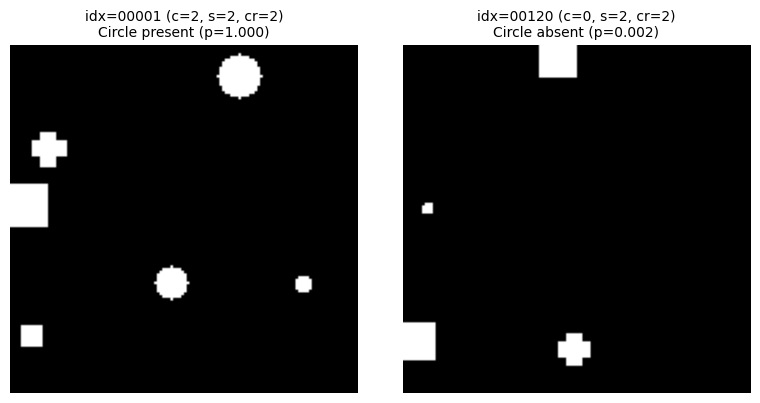

Image 1: 00001.png
Image 2: 00120.png


In [5]:


TARGET_IDX_WITH = 1   
TARGET_IDX_WITHOUT = 120 

val_csv = PROJECT_ROOT / 'data' / 'aixi_shape' / 'val' / 'dades.csv'
val_dir = PROJECT_ROOT / 'data' / 'aixi_shape' / 'val'

with open(val_csv) as f:
    rows = list(csv.DictReader(f, delimiter=';'))


def get_metadata_for_idx(target_idx, csv_rows):
    for r in csv_rows:
        if int(r['']) == target_idx:
            return (target_idx, int(r['c']), int(r['s']), int(r['cr']))
    raise ValueError(f"Index {target_idx} not found in CSV.")


img_with = get_metadata_for_idx(TARGET_IDX_WITH, rows)
img_without = get_metadata_for_idx(TARGET_IDX_WITHOUT, rows)

print(f"Loaded metadata for indices: {img_with[0]} and {img_without[0]}")


img_transform = transforms.Compose([
    transforms.Grayscale(),
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

nn_model.to(DEVICE)
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
for ax, (idx, c, s, cr) in zip(axes, [img_with, img_without]):
    img = Image.open(val_dir / f'{idx:05d}.png')
    
    t = img_transform(img.convert('L')).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        p = nn_model(t).item()
        
    ax.imshow(np.array(img), cmap='gray')
    label = 'Circle present' if p > 0.5 else 'Circle absent'
    ax.set_title(f'idx={idx:05d} (c={c}, s={s}, cr={cr})\n{label} (p={p:.3f})', fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()

print(f'Image 1: {img_with[0]:05d}.png')
print(f'Image 2: {img_without[0]:05d}.png')

TCAV device: cpu
Circle present: torch.Size([200, 1, 128, 128])
Circle absent:  torch.Size([200, 1, 128, 128])

[1] Running TCAV: circle_full vs randoms...


/home/dlc/VisualTCAV/.venv/lib/python3.13/site-packages/captum/concept/_core/tcav.py:325: UserWarning: Using default classifier for TCAV which keeps input both train and test datasets in the memory. Consider defining your own classifier that doesn't rely heavily on memory, for large number of concepts, by extending `Classifer` abstract class
  self.classifier = DefaultClassifier()


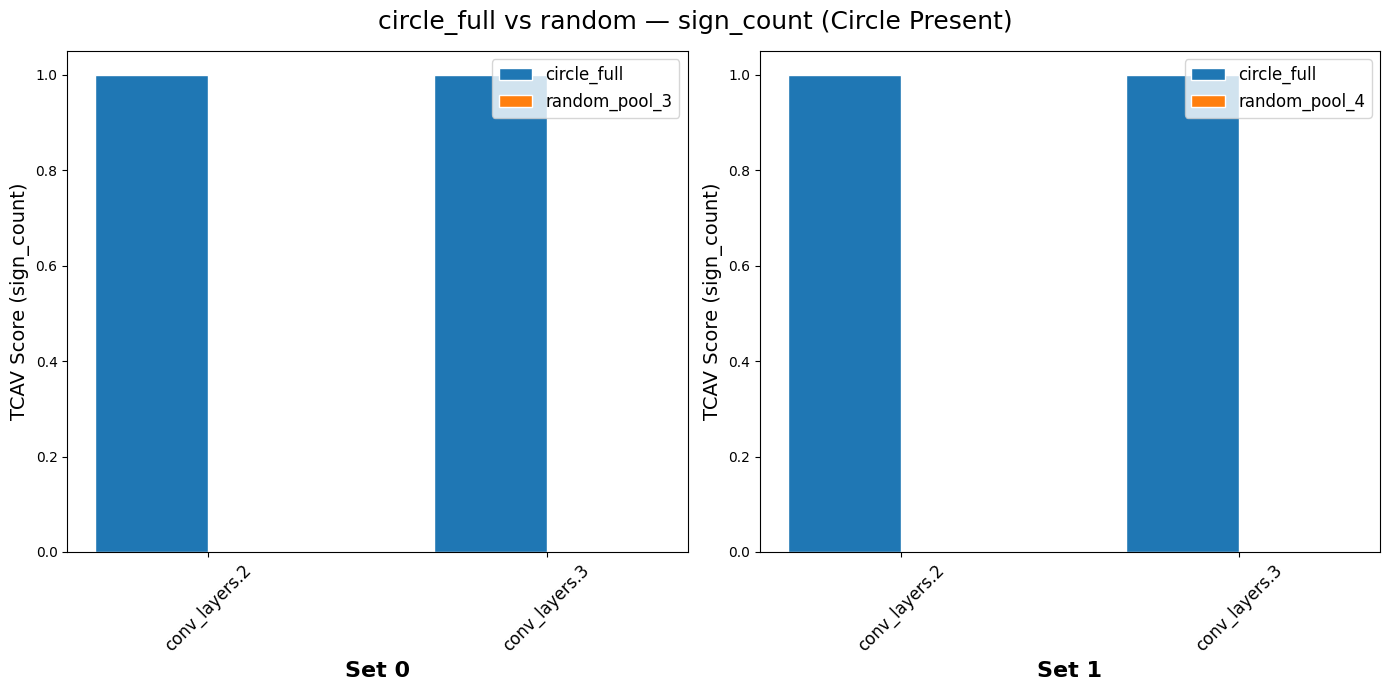

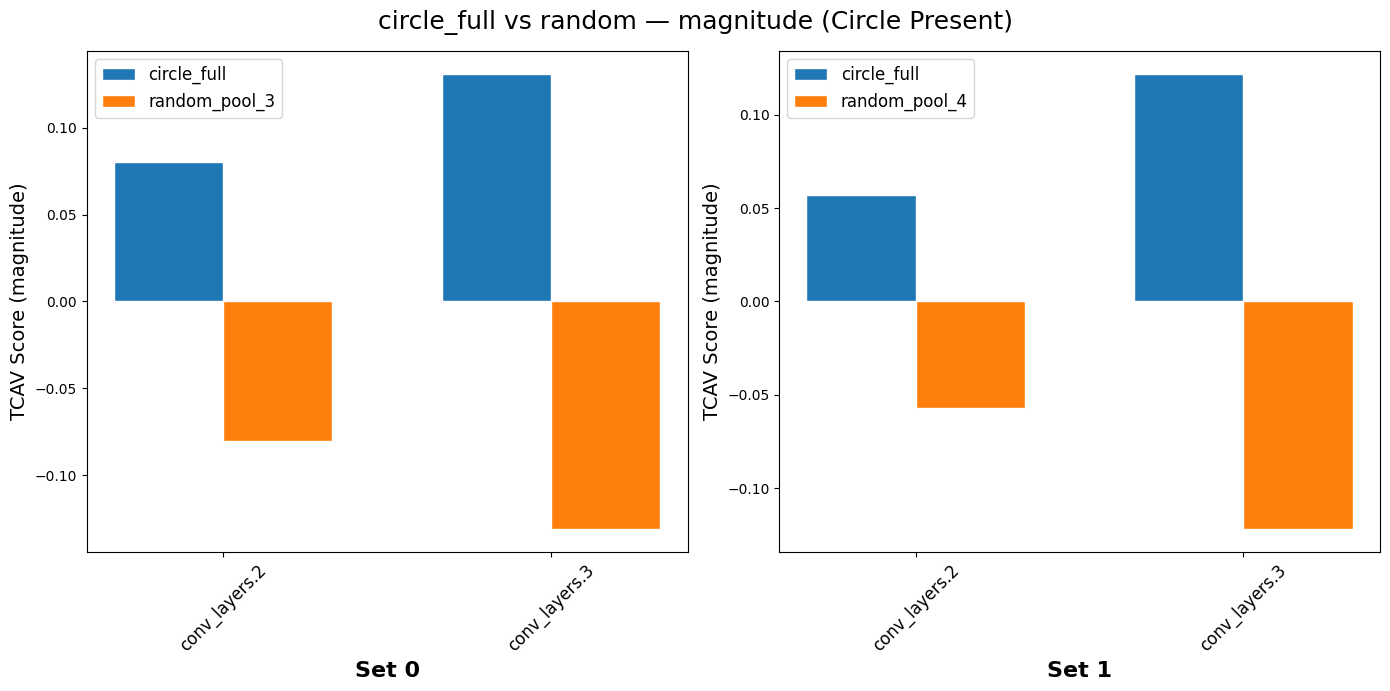


[2] Running TCAV: all concepts (Circle Present)...


/home/dlc/VisualTCAV/.venv/lib/python3.13/site-packages/captum/_utils/models/linear_model/train.py:409: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  bias_values = torch.FloatTensor([sklearn_model.intercept_]).to(  # type: ignore


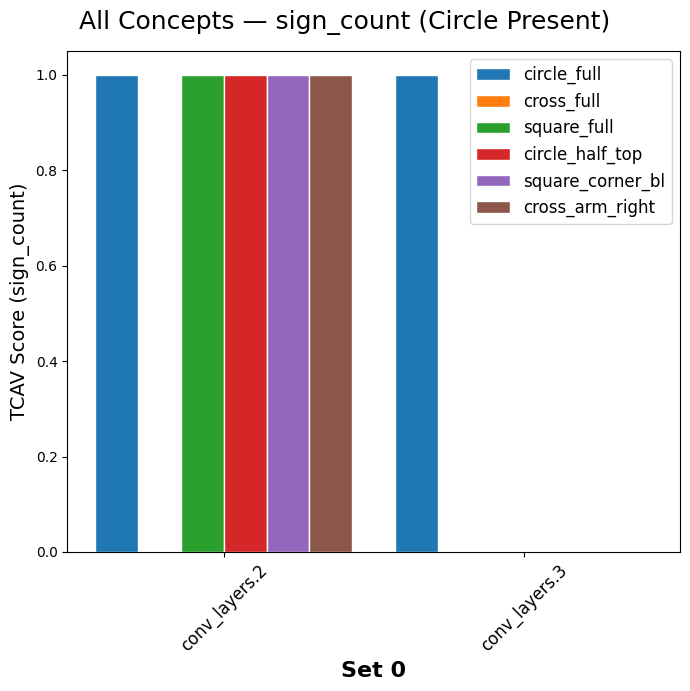

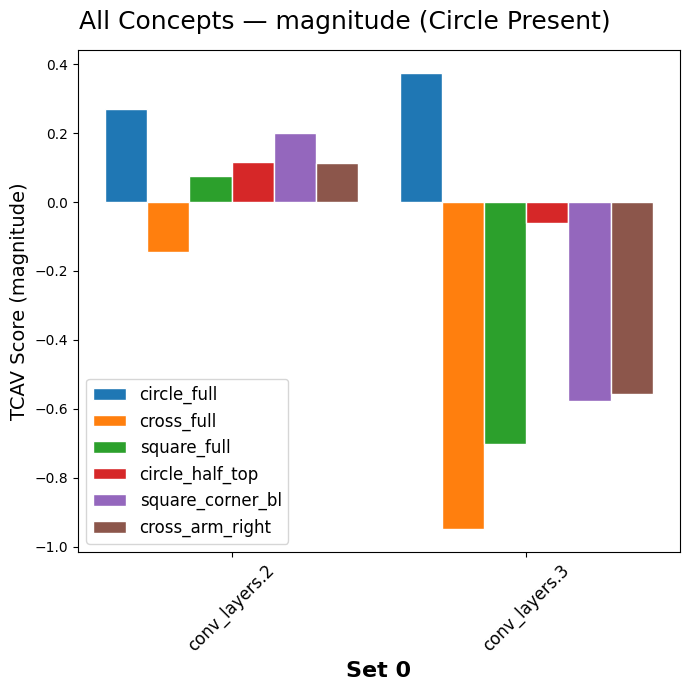


[3] Running TCAV: all concepts (Circle Absent)...


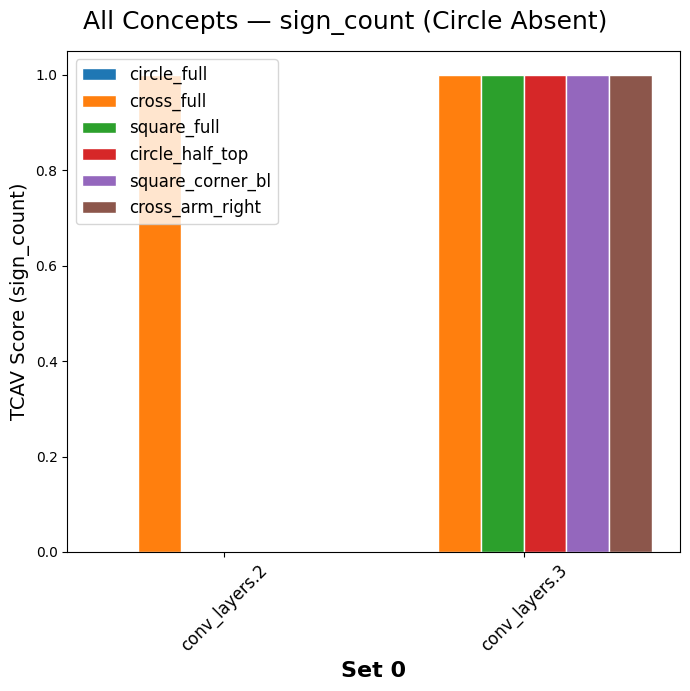

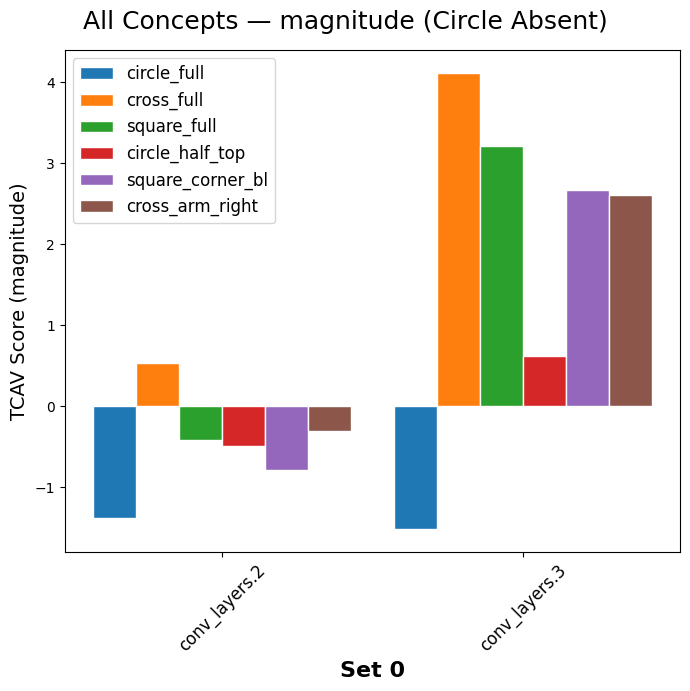


[4] Running TCAV: statistical significance...

=== Statistical Significance ===

--- conv_layers.2 ---
  P1[mean, std]: 1.0, 0.0
  P2[mean, std]: 0.0, 0.0
  p-value: 0.0 → Disjoint (zero var)
  P1[mean, std]: 0.003, 0.005
  P2[mean, std]: 0.997, 0.005
  p-value: 3.043e-09 → Disjoint


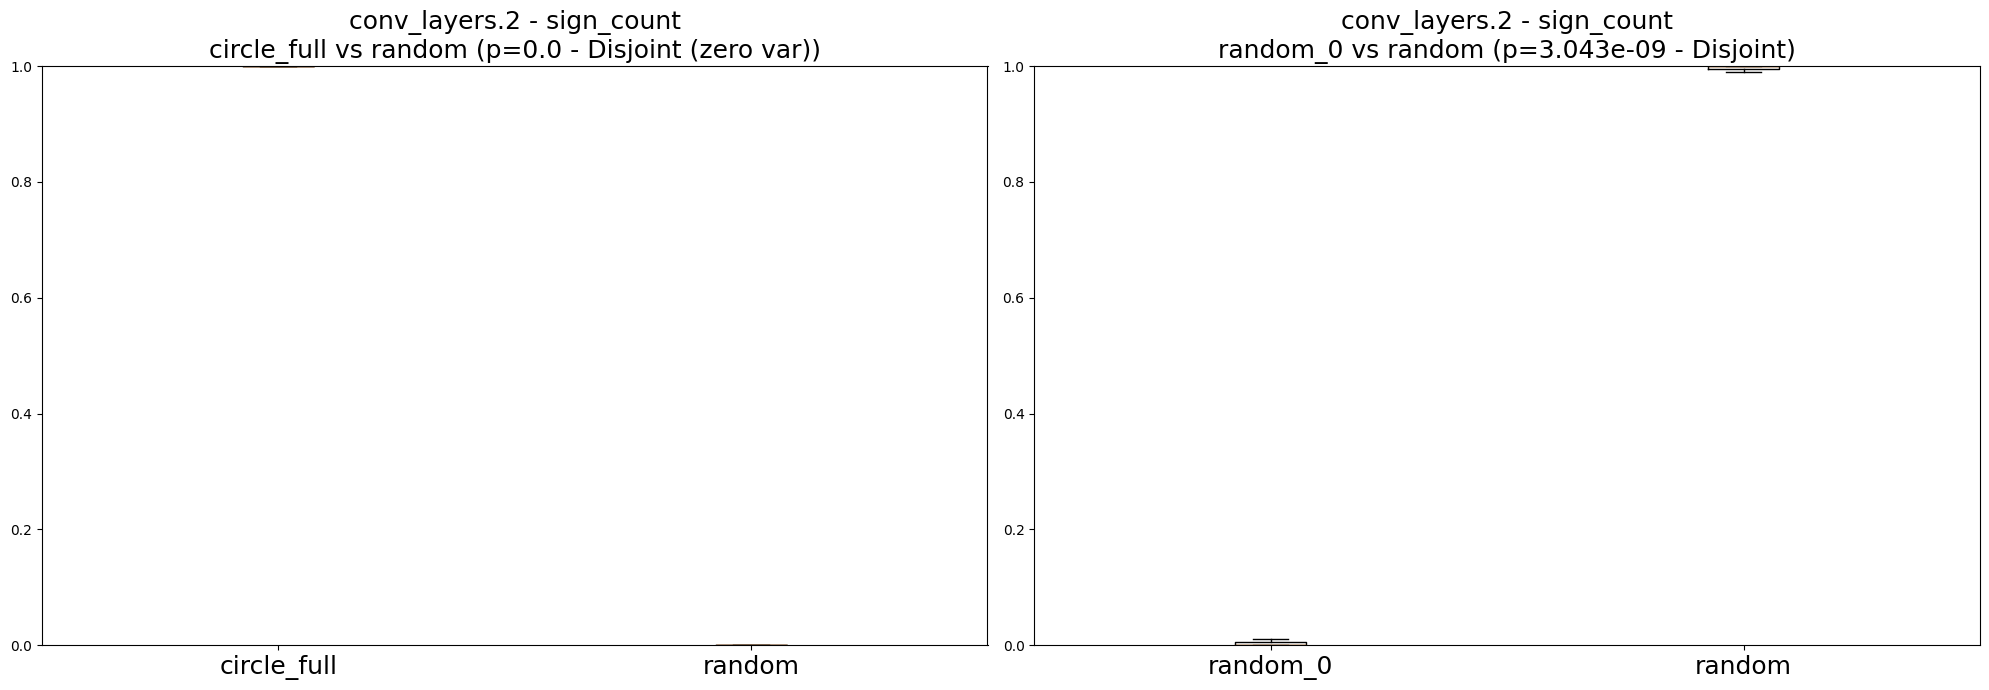


--- conv_layers.3 ---
  P1[mean, std]: 1.0, 0.0
  P2[mean, std]: 0.0, 0.0
  p-value: 0.0 → Disjoint (zero var)
  P1[mean, std]: 0.012, 0.016
  P2[mean, std]: 0.988, 0.016
  p-value: 4.877e-07 → Disjoint


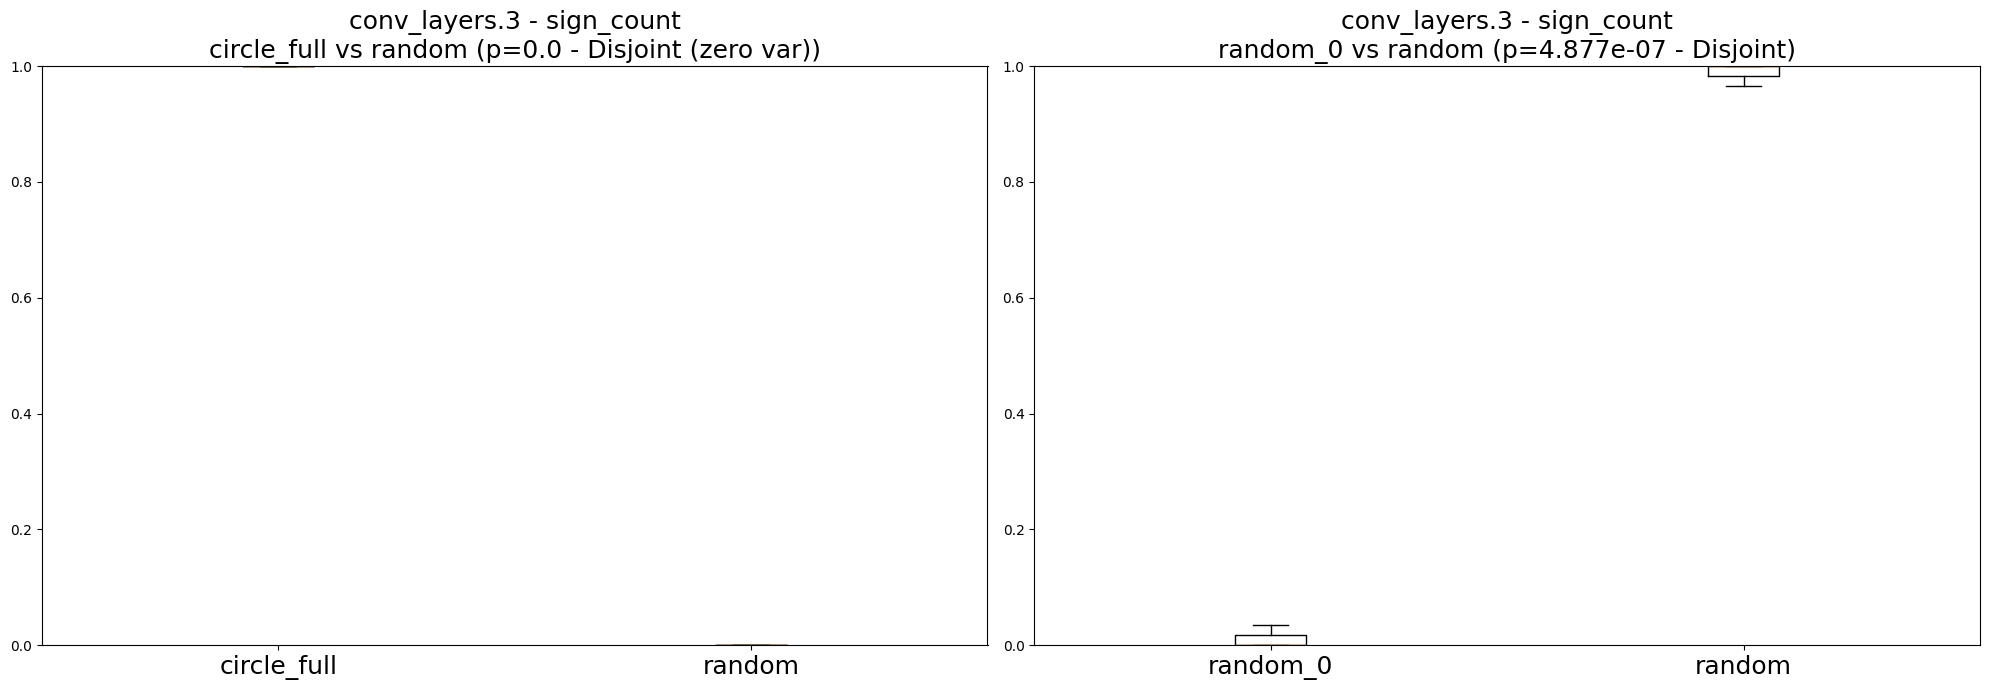

5935

In [6]:
##############################################
# Captum TCAV — Circle Detection Model
##############################################
#
# ┌─────────────────────────────────────────────────────────────────┐
# │ PRE-SIGMOID LOGIT APPROACH (faithful to Kim et al. 2018)       │
# │                                                                 │
# │ TCAV computes: S_C(x) = ∇_h f_k(x) · v_C                     │
# │ The directional derivative of the model output w.r.t. layer    │
# │ activations, dotted with the Concept Activation Vector.        │
# │                                                                 │
# │ Kim et al. use pre-softmax logits (not probabilities) so the   │
# │ gradient doesn't suffer from output saturation. We follow the  │
# │ same approach: the wrapper outputs pre-sigmoid logits as a     │
# │ 2-column tensor [-z, z], avoiding sigmoid saturation entirely. │
# │                                                                 │
# │ This means we use Captum's default LayerGradientXActivation    │
# │ (plain gradients), NOT LayerIntegratedGradients.               │
# │                                                                 │
# │ Additionally, Captum's DefaultClassifier has a device mismatch │
# │ bug on GPU (classes() returns CPU tensor, argmax returns CUDA).│
# │ We fix this with GPUClassifier below.                          │
# └─────────────────────────────────────────────────────────────────┘

import gc
import glob
import random
import numpy as np
import os
import copy
import matplotlib.pyplot as plt

import torch
from torch.utils.data import DataLoader, TensorDataset
from PIL import Image
from torchvision import transforms
from scipy.stats import ttest_ind

from captum.concept import TCAV, Concept
from captum.concept._utils.data_iterator import dataset_to_dataloader, CustomIterableDataset
from captum.concept._utils.common import concepts_to_str
from captum.concept._utils.classifier import Classifier
from captum._utils.models.linear_model.model import SkLearnSGDClassifier

# ── GPU-safe classifier (fixes Captum's device mismatch bug) ─────────
# Captum's DefaultClassifier crashes on GPU because:
#   1. self.lm.classes() returns a CPU tensor
#   2. torch.argmax(predict, dim=1) returns a CUDA tensor
#   3. CPU tensor indexed by CUDA tensor → RuntimeError
# This classifier keeps everything on the same device.

class GPUClassifier(Classifier):
    def __init__(self):
        self.lm = SkLearnSGDClassifier(alpha=0.01, max_iter=1000, tol=1e-3)

    def train_and_eval(self, dataloader, test_split_ratio=0.33, **kwargs):
        inputs = []
        labels = []
        for inp, label in dataloader:
            inputs.append(inp)
            labels.append(label)

        all_inputs = torch.cat(inputs)
        all_labels = torch.cat(labels)
        device = all_inputs.device

        # Shuffle and split
        z_list = list(zip(all_inputs, all_labels))
        random.shuffle(z_list)
        test_size = int(test_split_ratio * len(z_list))
        z_test, z_train = z_list[:test_size], z_list[test_size:]
        x_test, y_test = zip(*z_test)
        x_train, y_train = zip(*z_train)
        x_train, x_test = torch.stack(x_train), torch.stack(x_test)
        y_train, y_test = torch.stack(y_train), torch.stack(y_test)

        self.lm.device = device
        self.lm.fit(DataLoader(TensorDataset(x_train, y_train)))

        predict = self.lm(x_test)
        # FIX: move classes() to the same device as argmax output
        classes = self.lm.classes().to(device)
        predict = classes[torch.argmax(predict, dim=1)]
        score = predict.long() == y_test.long()

        return {"accs": score.float().mean()}

    def weights(self):
        weights = self.lm.representation()
        if weights.shape[0] == 1:
            return torch.stack([-1 * weights[0], weights[0]])
        return weights

    def classes(self):
        return self.lm.classes().detach().numpy()

# ── 1. Setup ─────────────────────────────────────────────────────────

DEVICE = torch.device('cpu')
CONCEPTS_DIR = str(PROJECT_ROOT / 'data' / 'concepts')
GLOBAL_TEST_DIR = str(PROJECT_ROOT / 'data' / 'aixi_shape' / 'val_global_test')
CIRCLE_PRESENT_IDX = 1
CIRCLE_ABSENT_IDX = 0
print(f"TCAV device: {DEVICE}")

grayscale_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

# ── 2. Pre-sigmoid logit wrapper ─────────────────────────────────────
# Captum TCAV expects [B, num_classes] output. Following Kim et al.,
# we output PRE-SIGMOID logits (not probabilities) to avoid sigmoid
# saturation killing gradients. Output: [-z, z] where z is the raw logit.

class LogitWrapper(torch.nn.Module):
    def __init__(self, model):
        super().__init__()
        self._inner = model
        self.conv_layers = model.conv_layers
        self.fc_layers = model.fc_layers
        self.output = model.output

    def forward(self, x):
        x = x.to(next(self._inner.parameters()).device)
        x = self.conv_layers(x)
        x = torch.flatten(x, 1)
        x = self.fc_layers(x)
        z = self.output(x)  # raw logit, NO sigmoid
        return torch.cat([-z, z], dim=1)

tcav_model = LogitWrapper(copy.deepcopy(nn_model).to(DEVICE))
tcav_model.eval()

# ── 3. Helpers ───────────────────────────────────────────────────────

def get_tensor_from_filename(filename):
    img = Image.open(filename).convert('L')
    return grayscale_transform(img)

def assemble_concept(name, id, concepts_path=CONCEPTS_DIR):
    concept_path = os.path.join(concepts_path, name) + "/"
    dataset = CustomIterableDataset(get_tensor_from_filename, concept_path)
    concept_iter = dataset_to_dataloader(dataset)
    return Concept(id=id, name=name, data_iter=concept_iter)

def load_test_images(class_dir):
    tensors = []
    for f in sorted(glob.glob(os.path.join(class_dir, '*.png'))):
        tensors.append(get_tensor_from_filename(f))
    return torch.stack(tensors)

def format_float(f):
    return float('{:.3f}'.format(f) if abs(f) >= 0.0005 else '{:.3e}'.format(f))

def plot_tcav_scores(experimental_sets, tcav_scores, layers, title, metric='sign_count'):
    n_sets = len(experimental_sets)
    fig, ax = plt.subplots(1, n_sets, figsize=(7 * n_sets, 7))
    if n_sets == 1:
        ax = [ax]

    for idx_es, concepts in enumerate(experimental_sets):
        concepts_key = concepts_to_str(concepts)
        n_concepts = len(concepts)
        barWidth = 1 / (n_concepts + 1)

        pos = [np.arange(len(layers))]
        for i in range(1, n_concepts):
            pos.append([(x + barWidth) for x in pos[i-1]])

        for i in range(n_concepts):
            val = [format_float(scores[metric][i])
                   for _, scores in tcav_scores[concepts_key].items()]
            ax[idx_es].bar(pos[i], val, width=barWidth, edgecolor='white',
                           label=concepts[i].name)

        ax[idx_es].set_xlabel(f'Set {idx_es}', fontweight='bold', fontsize=16)
        ax[idx_es].set_xticks([r + barWidth * (n_concepts - 1) / 2 for r in range(len(layers))])
        ax[idx_es].set_xticklabels(layers, fontsize=12, rotation=45)
        ax[idx_es].legend(fontsize=12)
        if metric == 'sign_count':
            ax[idx_es].set_ylim([0, 1.05])
        ax[idx_es].set_ylabel(f'TCAV Score ({metric})', fontsize=14)

    plt.suptitle(title, fontsize=18)
    plt.tight_layout()
    plt.show()

# ── 4. Concepts ──────────────────────────────────────────────────────

circle_full   = assemble_concept("circle_full",      0)
cross_full    = assemble_concept("cross_full",        1)
square_full   = assemble_concept("square_full",       2)
circle_half   = assemble_concept("circle_half_top",   3)
square_corner = assemble_concept("square_corner_bl",  4)
cross_arm     = assemble_concept("cross_arm_right",   5)

random_0 = assemble_concept("random_0", 10)
random_1 = assemble_concept("random_1", 11)
random_2 = assemble_concept("random_pool_3", 12)
random_3 = assemble_concept("random_pool_4", 13)

# ── 5. Layers & TCAV instance ────────────────────────────────────────

layers = ['conv_layers.2', 'conv_layers.3']

mytcav = TCAV(
    model=tcav_model,
    layers=layers,
    model_id = "Circle_Large"
    
)

# ── 6. Load test images ──────────────────────────────────────────────

circle_present_tensors = load_test_images(os.path.join(GLOBAL_TEST_DIR, 'circle_present')).to(DEVICE)
circle_absent_tensors = load_test_images(os.path.join(GLOBAL_TEST_DIR, 'circle_absent')).to(DEVICE)
print(f"Circle present: {circle_present_tensors.shape}")
print(f"Circle absent:  {circle_absent_tensors.shape}")

# ── 7. Experimental sets ─────────────────────────────────────────────

experimental_sets_rand = [
    [circle_full, random_2],
    [circle_full, random_3],
]

experimental_sets_all = [
    [circle_full, cross_full, square_full, circle_half, square_corner, cross_arm],
]

# ══════════════════════════════════════════════════════════════════════
# EXPERIMENT 1: circle_full vs randoms
# ══════════════════════════════════════════════════════════════════════

print("\n[1] Running TCAV: circle_full vs randoms...")
scores_rand = mytcav.interpret(
    inputs=circle_present_tensors,
    experimental_sets=experimental_sets_rand,
    target=CIRCLE_PRESENT_IDX,
)

plot_tcav_scores(experimental_sets_rand, scores_rand, layers,
                 title='circle_full vs random — sign_count (Circle Present)')
plot_tcav_scores(experimental_sets_rand, scores_rand, layers,
                 title='circle_full vs random — magnitude (Circle Present)',
                 metric='magnitude')

# ══════════════════════════════════════════════════════════════════════
# EXPERIMENT 2: All concepts head-to-head (Circle Present)
# ══════════════════════════════════════════════════════════════════════

print("\n[2] Running TCAV: all concepts (Circle Present)...")
scores_all_present = mytcav.interpret(
    inputs=circle_present_tensors,
    experimental_sets=experimental_sets_all,
    target=CIRCLE_PRESENT_IDX,
)

plot_tcav_scores(experimental_sets_all, scores_all_present, layers,
                 title='All Concepts — sign_count (Circle Present)')
plot_tcav_scores(experimental_sets_all, scores_all_present, layers,
                 title='All Concepts — magnitude (Circle Present)',
                 metric='magnitude')

# ══════════════════════════════════════════════════════════════════════
# EXPERIMENT 3: All concepts head-to-head (Circle Absent)
# ══════════════════════════════════════════════════════════════════════

print("\n[3] Running TCAV: all concepts (Circle Absent)...")
scores_all_absent = mytcav.interpret(
    inputs=circle_absent_tensors,
    experimental_sets=experimental_sets_all,
    target=CIRCLE_ABSENT_IDX,
)

plot_tcav_scores(experimental_sets_all, scores_all_absent, layers,
                 title='All Concepts — sign_count (Circle Absent)')
plot_tcav_scores(experimental_sets_all, scores_all_absent, layers,
                 title='All Concepts — magnitude (Circle Absent)',
                 metric='magnitude')

# Free experiments 1-3
del scores_rand, scores_all_present, scores_all_absent
gc.collect()

## Amb Cercles

In [7]:
local_explainer = LocalVisualTCAV(
    test_image_filename=f'{img_with[0]:05d}.png',
    m_steps=80,
    model=vtcav_model,
    concept_images_dir=CONCEPTS_DIR,
    test_images_dir=TEST_IMAGES_DIR,
    random_images_folder='random_pool_4', # Same distribution idk
    cav_method=METHOD_CAV,
    device=DEVICE,
)

local_explainer.setConcepts(CONCEPTS)
local_explainer.setLayers(['conv_layers.0', 'conv_layers.1', 'conv_layers.2', 'conv_layers.3'])

predictions = local_explainer.predict(no_sort=True)
predictions.info()

print(f'\nAvailable layers: {vtcav_model.getLayerNames()}')


Model: FlexNet_CircleLarge
    Image     Class name Confidence
00001.png Circle present       1.00

Available layers: ['conv_layers', 'conv_layers.0', 'conv_layers.0.0', 'conv_layers.1', 'conv_layers.1.0', 'conv_layers.2', 'conv_layers.2.0', 'conv_layers.3', 'conv_layers.3.0', 'fc_layers', 'fc_layers.0', 'fc_layers.0.0', 'fc_layers.1', 'fc_layers.1.0', 'output']


```
  FlexibleTNet                                                                                                                                               
  ├── conv_layers          → Sequential (the whole conv block container)                                                                                     
  │   └── 0                → Sequential (first conv block: Conv2d + ReLU + BN + MaxPool)                                                                     
  │       ├── 0            → Conv2d(1, 8, 3x3)        ← conv_layers.0.0                                                                                      
  │       ├── 1            → ReLU()
  │       ├── 2            → BatchNorm2d(8)
  │       └── 3            → MaxPool2d(2)
  ├── fc_layers            → Sequential (the whole FC block container)
  │   └── 0                → Sequential (first FC block: Linear + Dropout + ReLU)
  │       ├── 0            → Linear(32768 → 32)        ← fc_layers.0.0
  │       ├── 1            → Dropout(0.2)
  │       └── 2            → ReLU()
  ├── output               → Linear(32 → 1)
  └── final_act            → Sigmoid()
  ```
  

In [8]:
local_explainer.explain(cache_cav=False, cache_random=False)

for concept_name in local_explainer.concepts:
    for layer_name in local_explainer.layers:
        cl = local_explainer.computations[layer_name][concept_name]
        attribs = {k: v.item() if isinstance(v, torch.Tensor) else v
                   for k, v in cl.attributions.items()}
        print(f'{concept_name} @ {layer_name}: {attribs}')

Layers: 100%|██████████| 4/4 [00:04<00:00,  1.03s/it]

circle_full @ conv_layers.0: {0: 0.17020931839942932, 1: 0.144302636384964}
circle_full @ conv_layers.1: {0: 0.12104756385087967, 1: 0.04221174120903015}
circle_full @ conv_layers.2: {0: 0.19070398807525635, 1: 0.0029370582196861506}
circle_full @ conv_layers.3: {0: 0.3025476336479187, 1: 0.0006276762578636408}
cross_full @ conv_layers.0: {0: 0.13063694536685944, 1: 0.11040105670690536}
cross_full @ conv_layers.1: {0: 0.006495807785540819, 1: 0.01115153543651104}
cross_full @ conv_layers.2: {0: 0.07404354214668274, 1: 0.0008143472368828952}
cross_full @ conv_layers.3: {0: 0.014950994402170181, 1: 1.7658983779256232e-05}
square_full @ conv_layers.0: {0: 0.1660458743572235, 1: 0.15517675876617432}
square_full @ conv_layers.1: {0: 0.004248753190040588, 1: 0.006493087857961655}
square_full @ conv_layers.2: {0: 0.09204219281673431, 1: 0.0012692395830526948}
square_full @ conv_layers.3: {0: 0.02044588513672352, 1: 1.895138484542258e-05}
circle_half_top @ conv_layers.0: {0: 0.1323708593845367

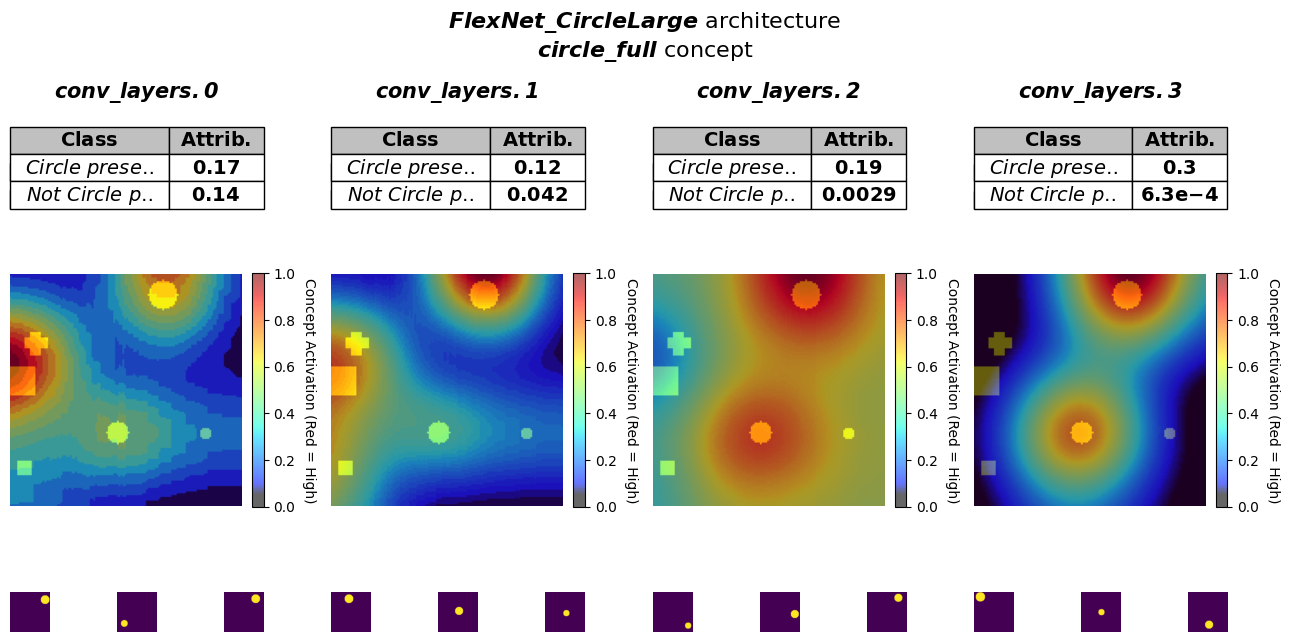

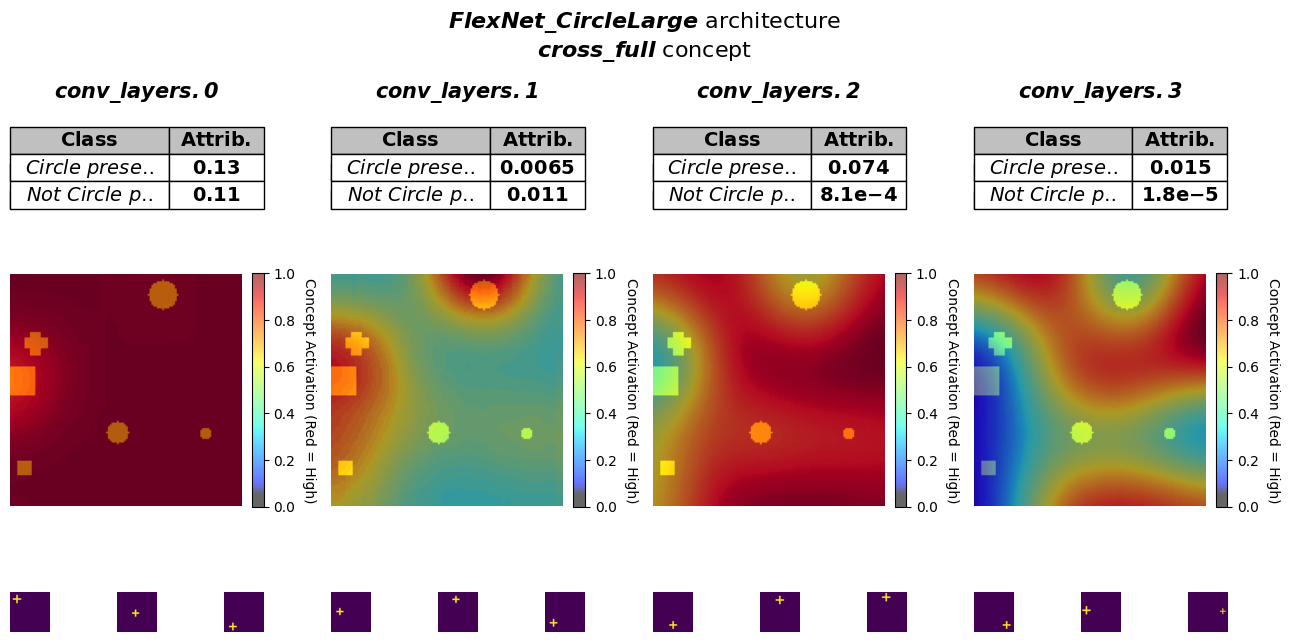

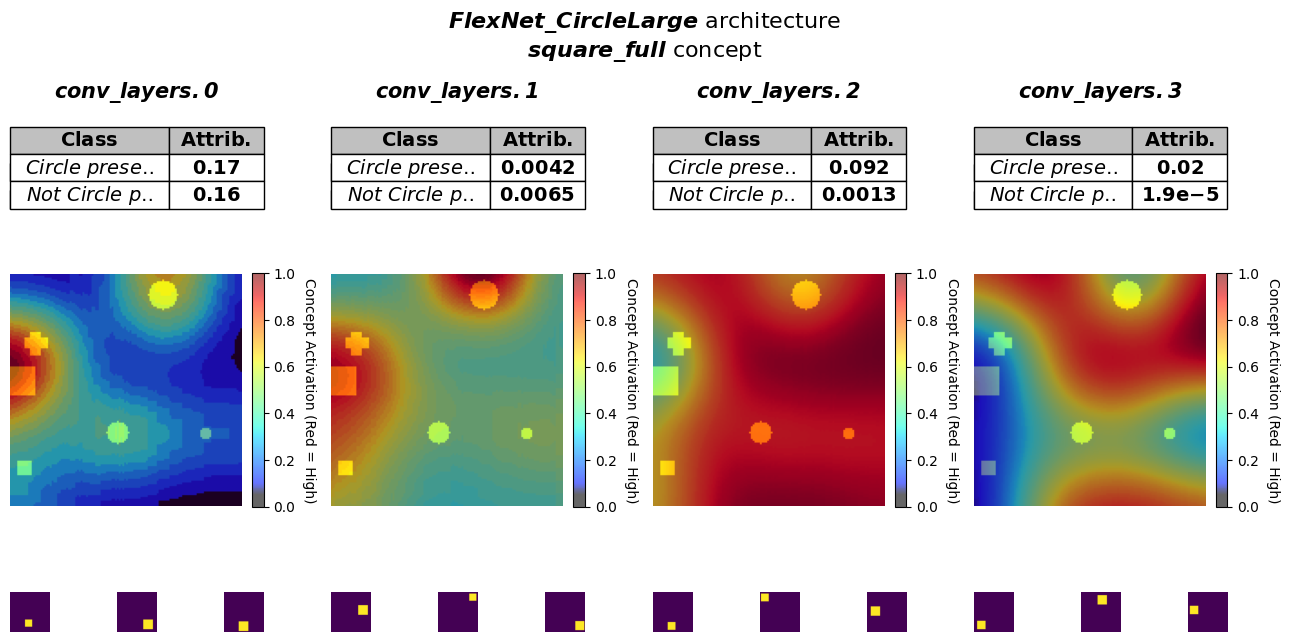

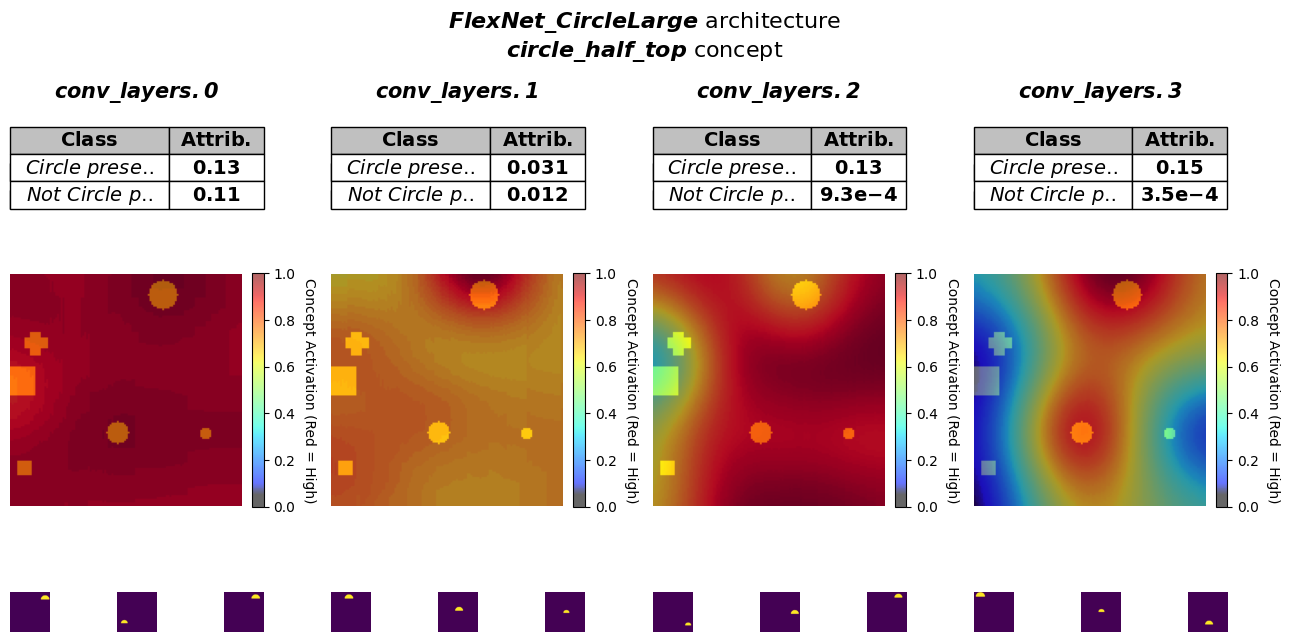

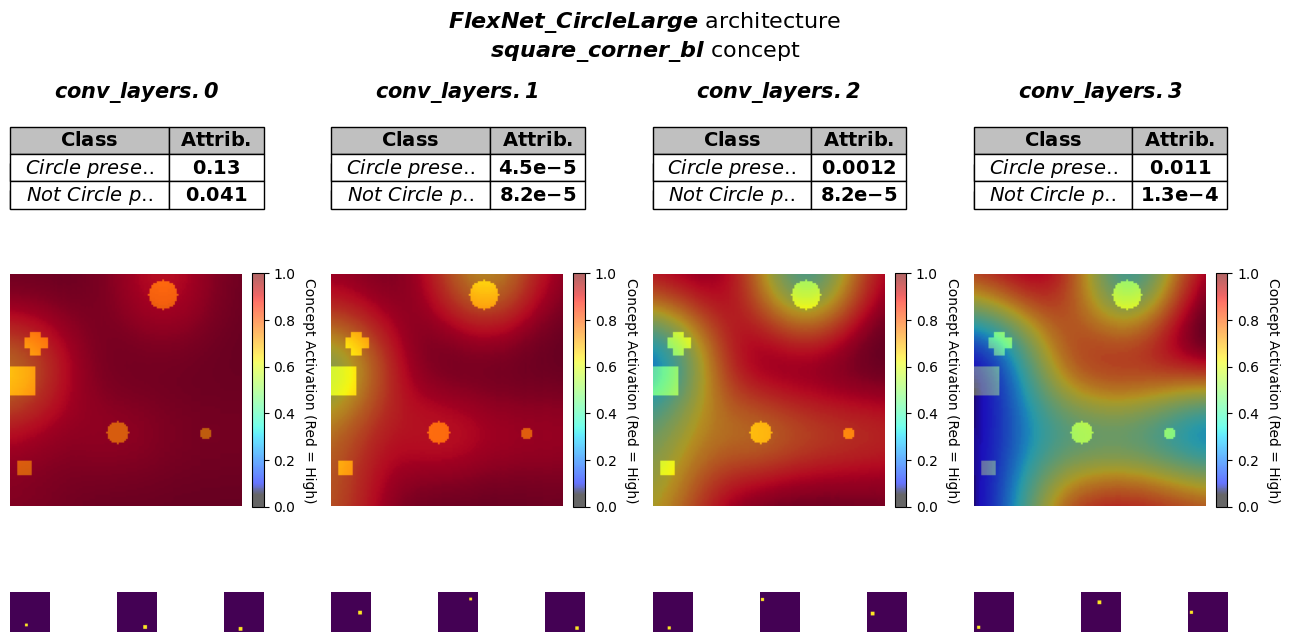

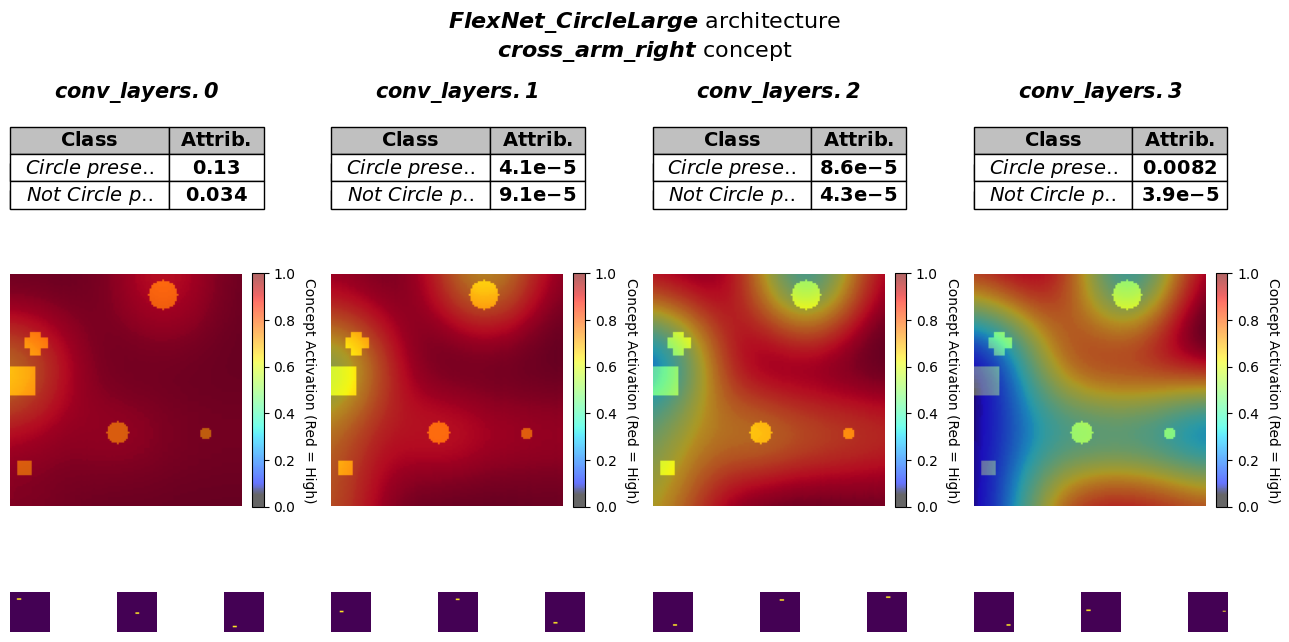

In [9]:
# Plot heatmaps
local_explainer.plot()

circle_full: norm=1.0843, emblem=(9.1887, 1.1466)
cross_full: norm=0.8669, emblem=(0.8537, 0.0000)
square_full: norm=1.2023, emblem=(6.6776, 0.5236)
circle_half_top: norm=0.8943, emblem=(1.2204, 0.0000)
square_corner_bl: norm=0.8398, emblem=(0.3765, 0.0000)
cross_arm_right: norm=0.8195, emblem=(0.3967, 0.0000)

Cosine similarities between CAV directions:
  circle_full vs cross_full: 0.8881
  circle_full vs square_full: 0.9731
  circle_full vs circle_half_top: 0.9328
  circle_full vs square_corner_bl: 0.6897
  circle_full vs cross_arm_right: 0.6480
  cross_full vs square_full: 0.8670
  cross_full vs circle_half_top: 0.9862
  cross_full vs square_corner_bl: 0.9282
  cross_full vs cross_arm_right: 0.9070
  square_full vs circle_half_top: 0.9010
  square_full vs square_corner_bl: 0.6484
  square_full vs cross_arm_right: 0.6048
  circle_half_top vs square_corner_bl: 0.8950
  circle_half_top vs cross_arm_right: 0.8696
  square_corner_bl vs cross_arm_right: 0.9979


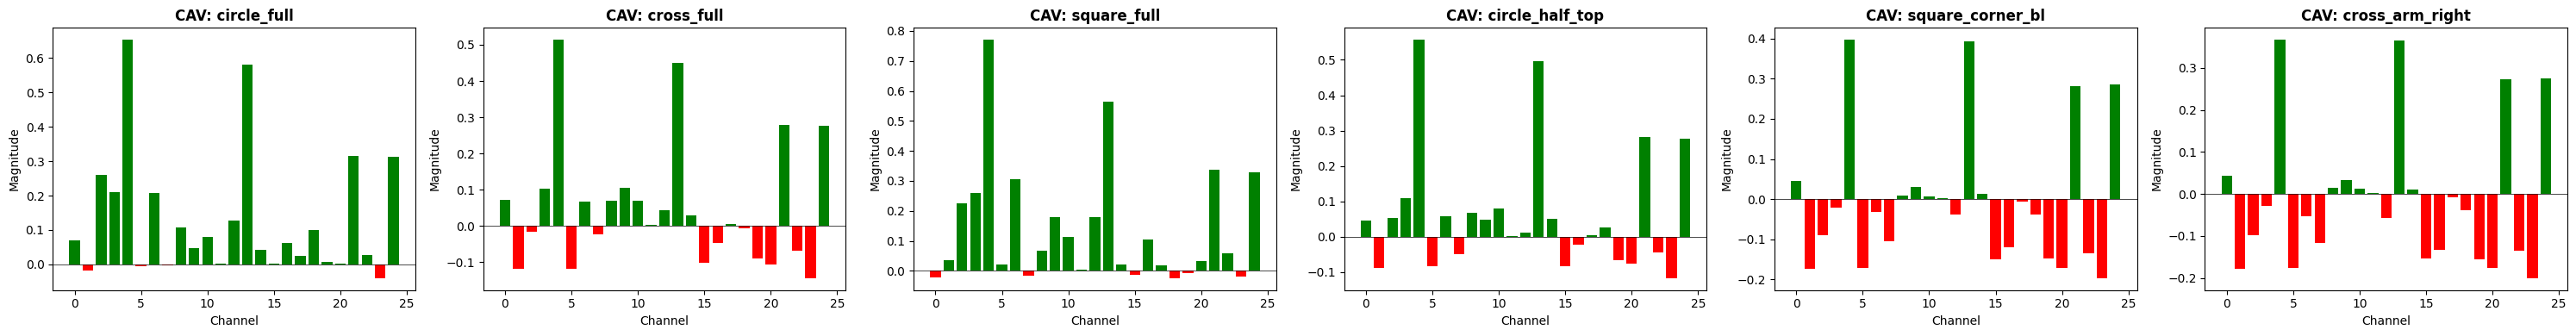

circle_full: norm=0.9770, emblem=(10.3198, 0.0000)
cross_full: norm=0.7565, emblem=(2.4444, 0.0000)
square_full: norm=0.8767, emblem=(1.8676, 0.0000)
circle_half_top: norm=0.7470, emblem=(0.9700, 0.0000)
square_corner_bl: norm=0.6609, emblem=(0.3491, 0.0000)
cross_arm_right: norm=0.6502, emblem=(0.3633, 0.0000)

Cosine similarities between CAV directions:
  circle_full vs cross_full: 0.8192
  circle_full vs square_full: 0.8035
  circle_full vs circle_half_top: 0.8816
  circle_full vs square_corner_bl: 0.5492
  circle_full vs cross_arm_right: 0.5039
  cross_full vs square_full: 0.8968
  cross_full vs circle_half_top: 0.9463
  cross_full vs square_corner_bl: 0.8451
  cross_full vs cross_arm_right: 0.7999
  square_full vs circle_half_top: 0.8862
  square_full vs square_corner_bl: 0.7832
  square_full vs cross_arm_right: 0.7360
  circle_half_top vs square_corner_bl: 0.8285
  circle_half_top vs cross_arm_right: 0.7961
  square_corner_bl vs cross_arm_right: 0.9927


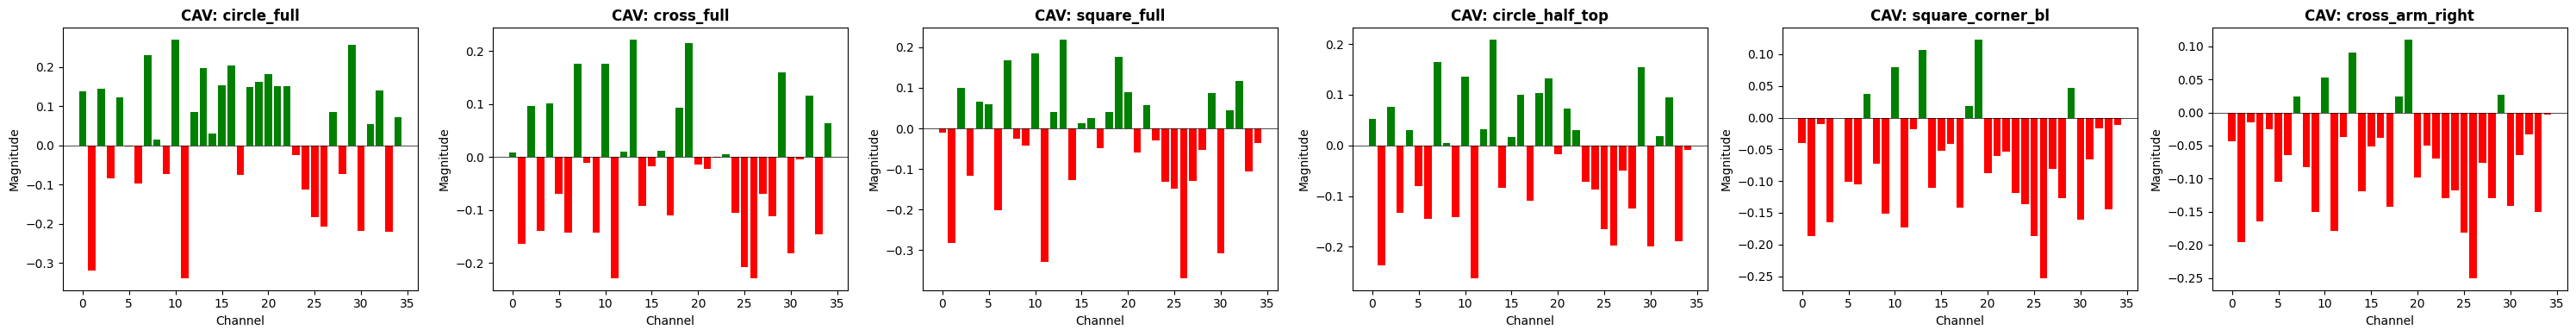

circle_full: norm=0.7007, emblem=(2.4878, 0.0000)
cross_full: norm=0.5977, emblem=(0.7359, 0.0000)
square_full: norm=0.7135, emblem=(0.7810, 0.0000)
circle_half_top: norm=0.6286, emblem=(0.9887, 0.0000)
square_corner_bl: norm=0.5385, emblem=(0.8250, 0.0000)
cross_arm_right: norm=0.5198, emblem=(0.8104, 0.0000)

Cosine similarities between CAV directions:
  circle_full vs cross_full: 0.8297
  circle_full vs square_full: 0.8618
  circle_full vs circle_half_top: 0.9305
  circle_full vs square_corner_bl: 0.7458
  circle_full vs cross_arm_right: 0.6903
  cross_full vs square_full: 0.9492
  cross_full vs circle_half_top: 0.9276
  cross_full vs square_corner_bl: 0.9151
  cross_full vs cross_arm_right: 0.8879
  square_full vs circle_half_top: 0.8929
  square_full vs square_corner_bl: 0.8423
  square_full vs cross_arm_right: 0.7981
  circle_half_top vs square_corner_bl: 0.8981
  circle_half_top vs cross_arm_right: 0.8614
  square_corner_bl vs cross_arm_right: 0.9944


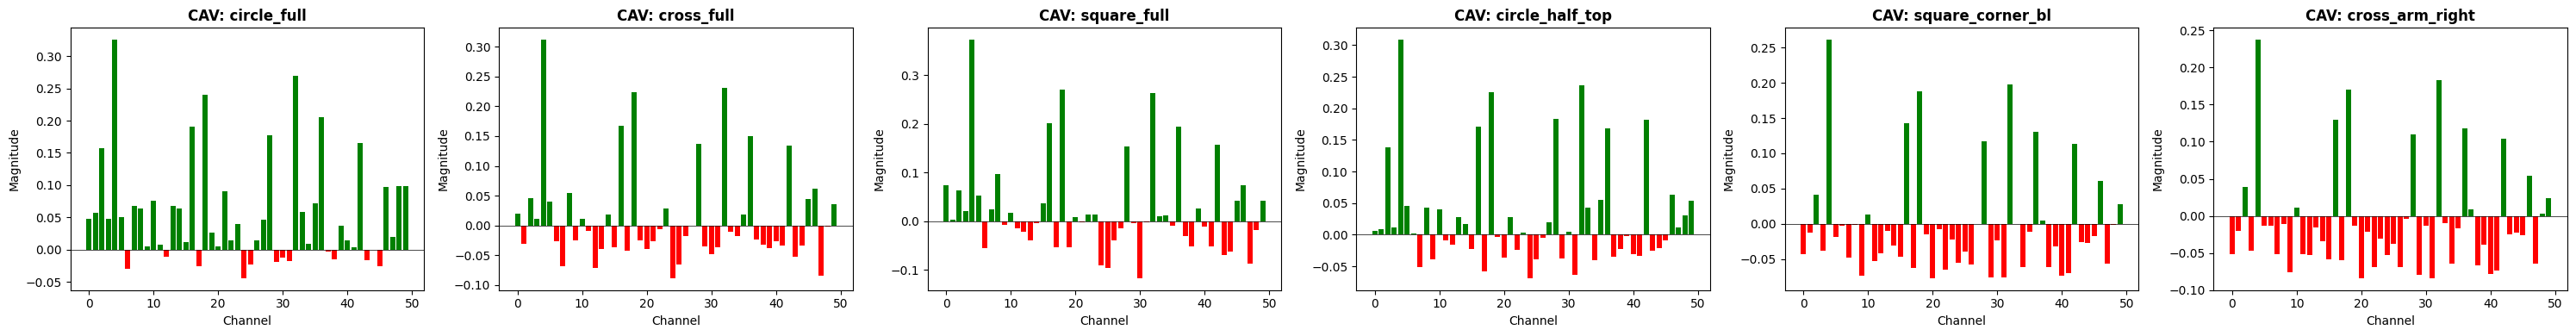

circle_full: norm=0.8280, emblem=(10.8632, 0.0000)
cross_full: norm=1.0210, emblem=(0.9377, 0.0000)
square_full: norm=1.1717, emblem=(0.9336, 0.0000)
circle_half_top: norm=0.9986, emblem=(1.2933, 0.0000)
square_corner_bl: norm=0.9787, emblem=(0.9462, 0.0000)
cross_arm_right: norm=0.9534, emblem=(0.9351, 0.0000)

Cosine similarities between CAV directions:
  circle_full vs cross_full: 0.6679
  circle_full vs square_full: 0.6654
  circle_full vs circle_half_top: 0.8623
  circle_full vs square_corner_bl: 0.6731
  circle_full vs cross_arm_right: 0.6685
  cross_full vs square_full: 0.9627
  cross_full vs circle_half_top: 0.9043
  cross_full vs square_corner_bl: 0.9942
  cross_full vs cross_arm_right: 0.9908
  square_full vs circle_half_top: 0.8801
  square_full vs square_corner_bl: 0.9554
  square_full vs cross_arm_right: 0.9390
  circle_half_top vs square_corner_bl: 0.9052
  circle_half_top vs cross_arm_right: 0.8971
  square_corner_bl vs cross_arm_right: 0.9973


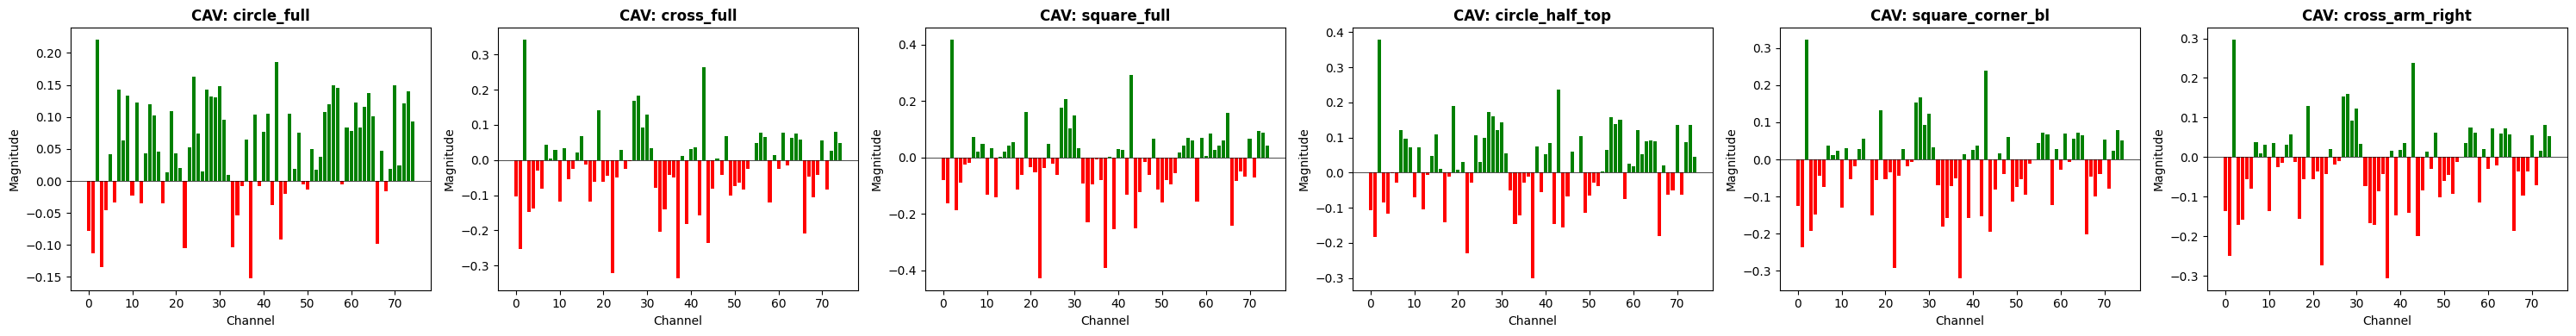

In [10]:
for x in [0, 1, 2, 3]:
    concept_names = local_explainer.concepts
    layer_name = local_explainer.layers[x]

    
    cavs = {}
    for cn in concept_names:
        cav = local_explainer.getCAVs(layer_name, cn)
        cavs[cn] = cav.direction
        print(f'{cn}: norm={cav.direction.norm():.4f}, '
            f'emblem=({cav.concept_emblem[0]:.4f}, {cav.concept_emblem[1]:.4f})')

    
    print('\nCosine similarities between CAV directions:')
    for a, b in combinations(concept_names, 2):
        cos = F.cosine_similarity(
            cavs[a].unsqueeze(0), cavs[b].unsqueeze(0)
        ).item()
        print(f'  {a} vs {b}: {cos:.4f}')

    
    fig, axes = plt.subplots(1, len(concept_names), figsize=(5 * len(concept_names), 4))
    for ax, name in zip(axes, concept_names):
        d = cavs[name].cpu().numpy()
        ax.bar(range(len(d)), d, color=['green' if v > 0 else 'red' for v in d])
        ax.set_title(f'CAV: {name}', fontweight='bold')
        ax.set_xlabel('Channel')
        ax.set_ylabel('Magnitude')
        ax.axhline(0, color='black', linewidth=0.5)
    plt.tight_layout()
    plt.show()

## Sense Cercles


Model: FlexNet_CircleLarge
    Image     Class name Confidence
00120.png Circle present       0.00


Layers: 100%|██████████| 4/4 [00:03<00:00,  1.08it/s]


circle_full @ conv_layers.0: {0: 0.017910800874233246, 1: 0.15070079267024994}
circle_full @ conv_layers.1: {0: 0.22113773226737976, 1: 0.13489779829978943}
circle_full @ conv_layers.2: {0: 0.018461262807250023, 1: 0.0014428215799853206}
circle_full @ conv_layers.3: {0: 0.0007334025576710701, 1: 0.0001994599588215351}
cross_full @ conv_layers.0: {0: 0.008524587377905846, 1: 0.12357452511787415}
cross_full @ conv_layers.1: {0: 0.11294965445995331, 1: 0.1179385632276535}
cross_full @ conv_layers.2: {0: 0.01584962196648121, 1: 0.0004721590084955096}
cross_full @ conv_layers.3: {0: 0.006006688345223665, 1: 0.0034930906258523464}
square_full @ conv_layers.0: {0: 0.018844081088900566, 1: 0.16609537601470947}
square_full @ conv_layers.1: {0: 0.09021814912557602, 1: 0.10248325765132904}
square_full @ conv_layers.2: {0: 0.020113449543714523, 1: 0.0004030594718642533}
square_full @ conv_layers.3: {0: 0.006575997918844223, 1: 0.003756321268156171}
circle_half_top @ conv_layers.0: {0: 0.0066156573

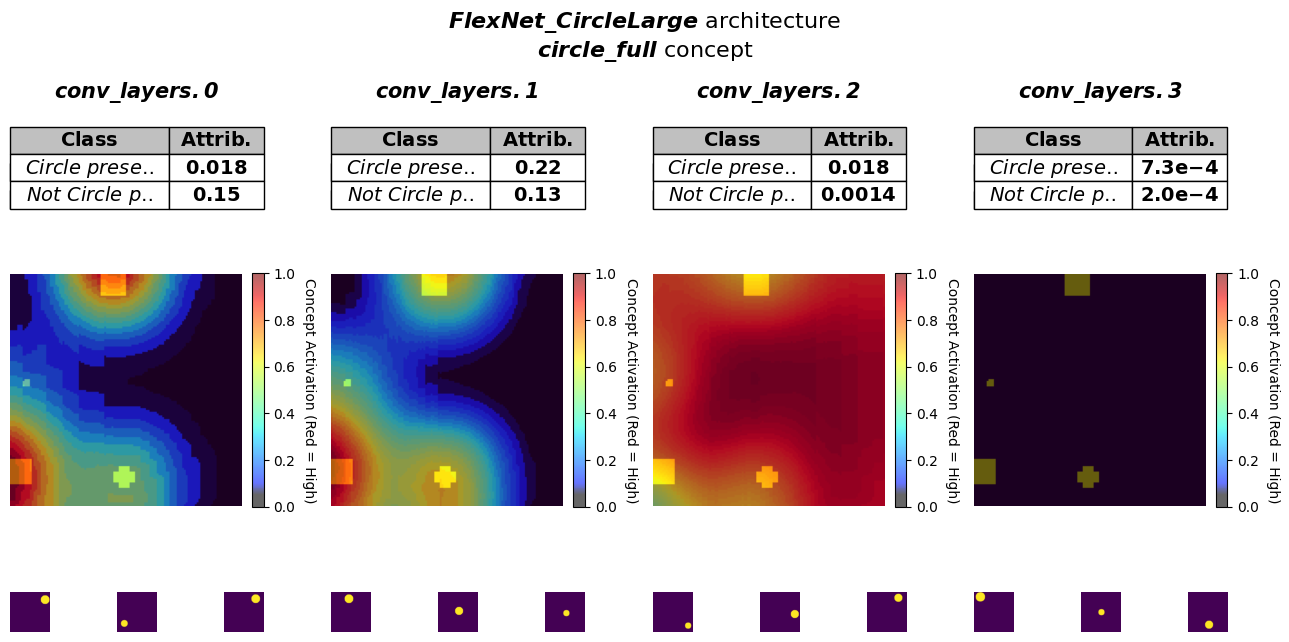

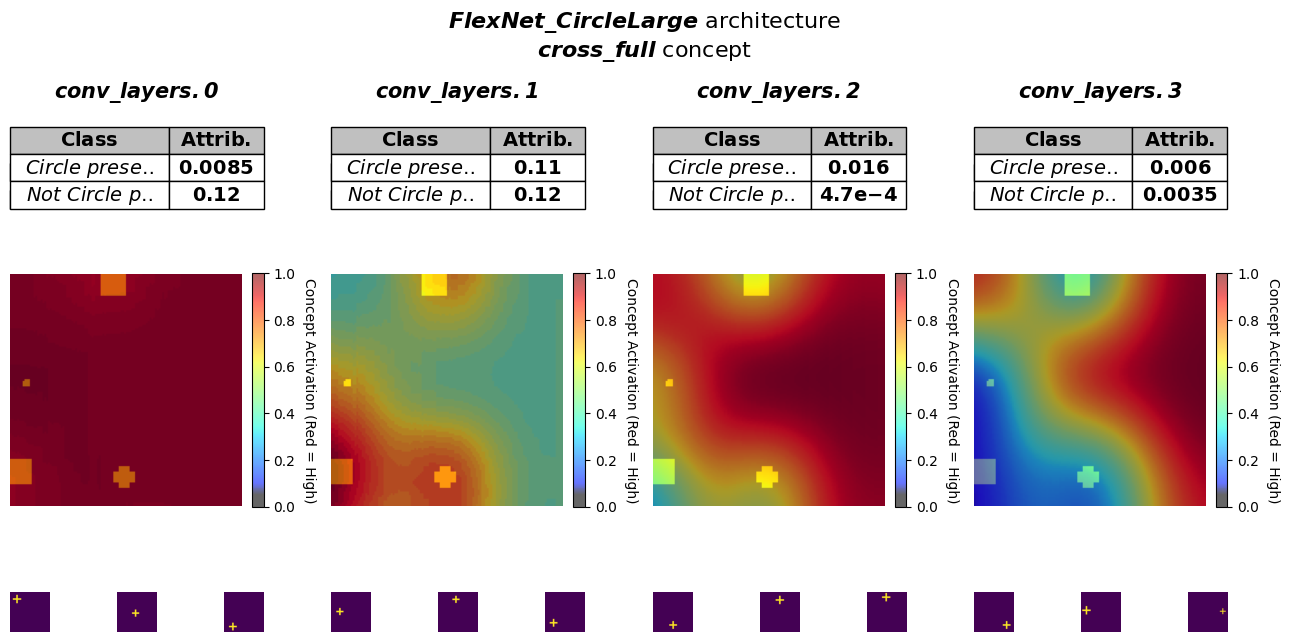

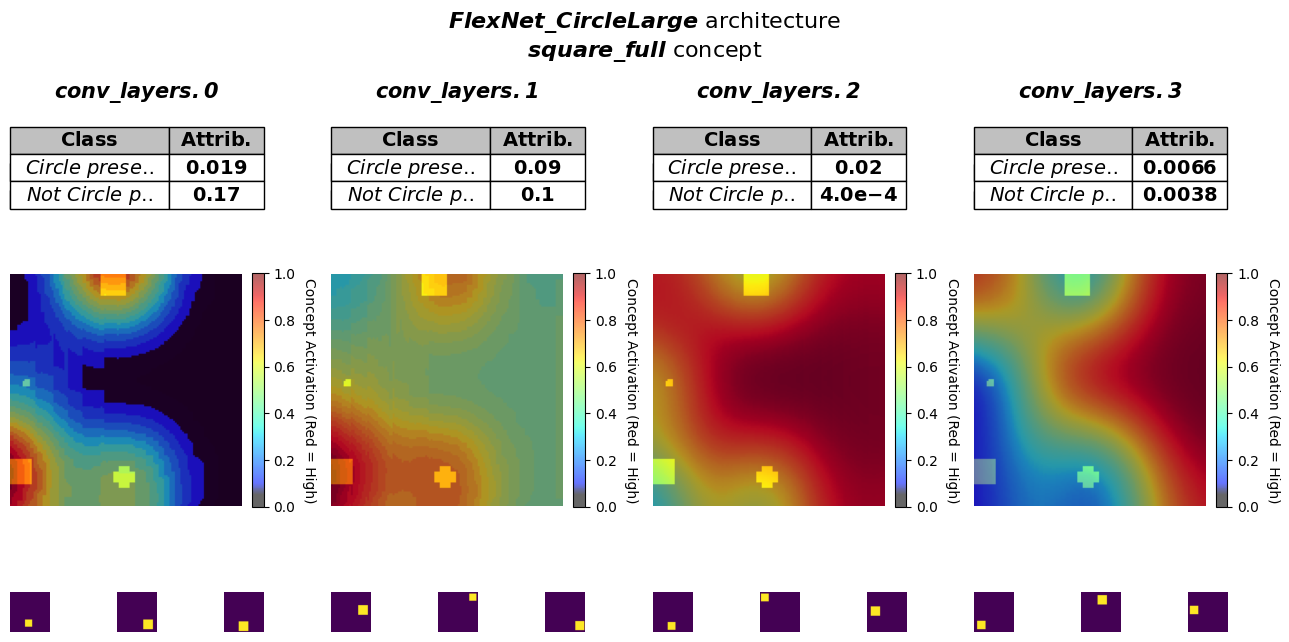

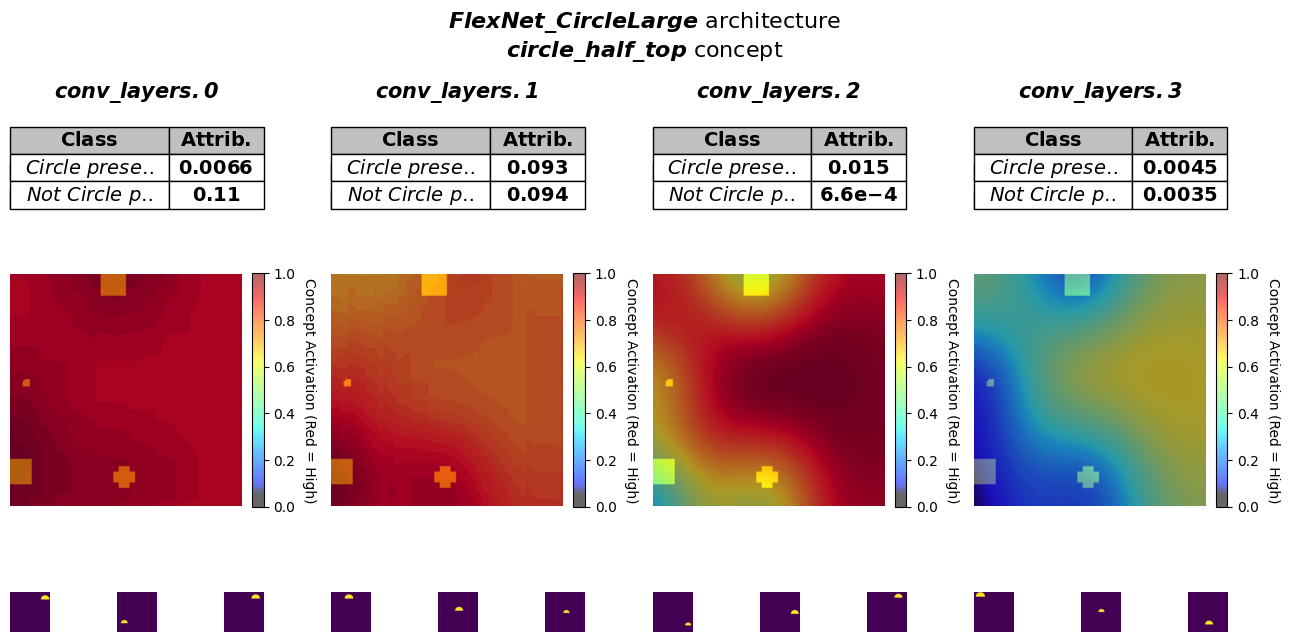

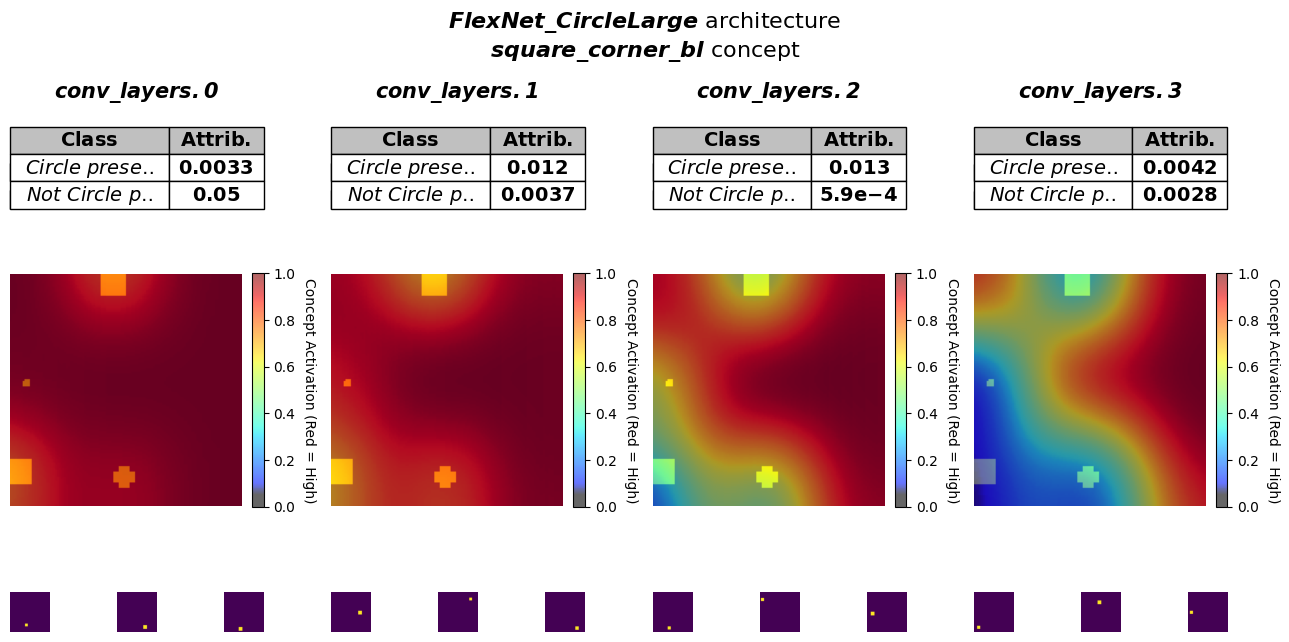

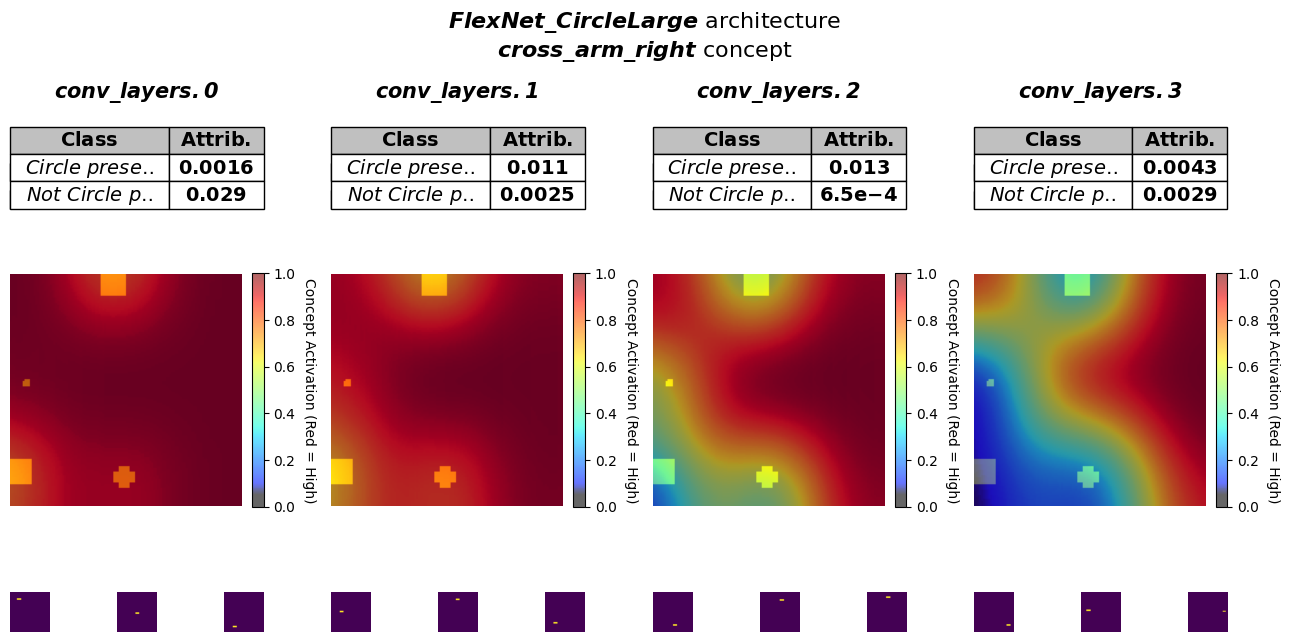

In [11]:
local_explainer2 = LocalVisualTCAV(
    test_image_filename=f'{img_without[0]:05d}.png',
    m_steps=50,
    model=vtcav_model,
    concept_images_dir=CONCEPTS_DIR,
    test_images_dir=TEST_IMAGES_DIR,
    random_images_folder='random_pool_4',
    cav_method='classifier',
    device=DEVICE,
)

local_explainer2.setConcepts(CONCEPTS)
local_explainer2.setLayers(['conv_layers.0', 'conv_layers.1', 'conv_layers.2', 'conv_layers.3'])

predictions2 = local_explainer2.predict(no_sort=True)
predictions2.info()

local_explainer2.explain(cache_cav=False, cache_random=False)

for concept_name in local_explainer2.concepts:
    for layer_name in local_explainer2.layers:
        cl = local_explainer2.computations[layer_name][concept_name]
        attribs = {k: v.item() if isinstance(v, torch.Tensor) else v
                   for k, v in cl.attributions.items()}
        print(f'{concept_name} @ {layer_name}: {attribs}')

local_explainer2.plot()

## Global Explanation

In [12]:
import shutil

# Select 200 images per grup as stated in the paper
circle_indices, no_circle_indices = [], []
for r in rows:
    idx, c = int(r['']), int(r['c'])
    if c > 0 and len(circle_indices) < 200:
        circle_indices.append(idx)
    elif c == 0 and len(no_circle_indices) < 200:
        no_circle_indices.append(idx)


global_test_dir = PROJECT_ROOT / 'data' / 'aixi_shape' / 'val_global_test'
for group_name, indices in [('circle_present', circle_indices), ('circle_absent', no_circle_indices)]:
    group_dir = global_test_dir / group_name
    group_dir.mkdir(parents=True, exist_ok=True)
    for idx in indices:
        src = val_dir / f'{idx:05d}.png'
        dst = group_dir / f'{idx:05d}.png'
        if not dst.exists():
            shutil.copy2(src, dst)

print(f'Circle present: {len(circle_indices)} images')
print(f'Circle absent:  {len(no_circle_indices)} images')
print(f'Test dir: {global_test_dir}')

Circle present: 200 images
Circle absent:  200 images
Test dir: /home/dlc/VisualTCAV/data/aixi_shape/val_global_test


In [13]:
global_circle = GlobalVisualTCAV(
    target_class='Circle present',
    test_images_folder='square_present',
    m_steps=80,
    model=vtcav_model,
    concept_images_dir=CONCEPTS_DIR,
    test_images_dir=str(global_test_dir),
    random_images_folder='random_pool_4',
    cav_method=METHOD_CAV,
    device=DEVICE,
)

global_circle.setConcepts(CONCEPTS)
global_circle.setLayers(['conv_layers.0', 'conv_layers.1', 'conv_layers.2', 'conv_layers.3'])

print('Running global explanation - Circle Present...')
global_circle.explain(cache_cav=False, cache_random=False)

Running global explanation - Circle Present...


Layers: 100%|██████████| 4/4 [00:16<00:00,  4.10s/it]


In [14]:
global_circle.statsInfo()


Model: FlexNet_CircleLarge | Class: Circle present | Folder: square_present
         Concept         Layer       Attrib. mean    Attrib. 95.45% CI
     circle_full conv_layers.0       0.18 ± 0.112       [0.164, 0.195]
                 conv_layers.1       0.153 ± 0.05        [0.146, 0.16]
                 conv_layers.2     0.132 ± 0.0838       [0.121, 0.144]
                 conv_layers.3      0.215 ± 0.139       [0.195, 0.234]
      cross_full conv_layers.0      0.148 ± 0.103       [0.133, 0.162]
                 conv_layers.1     0.0292 ± 0.038     [0.0238, 0.0346]
                 conv_layers.2    0.0403 ± 0.0351     [0.0353, 0.0452]
                 conv_layers.3  0.00443 ± 0.00629   [0.00354, 0.00532]
     square_full conv_layers.0      0.173 ± 0.107       [0.158, 0.189]
                 conv_layers.1     0.0235 ± 0.031     [0.0191, 0.0279]
                 conv_layers.2    0.0494 ± 0.0379      [0.044, 0.0547]
                 conv_layers.3  0.00677 ± 0.00775   [0.00568, 0.00787]


In [15]:
global_no_circle = GlobalVisualTCAV(
    target_class='Circle absent',  
    test_images_folder='square_absent',
    m_steps=80,
    model=vtcav_model,
    concept_images_dir=CONCEPTS_DIR,
    test_images_dir=str(global_test_dir),
    random_images_folder='random_pool_4',
    cav_method=METHOD_CAV,
    device=DEVICE,
)

global_no_circle.setConcepts(CONCEPTS)
global_no_circle.setLayers(['conv_layers.0', 'conv_layers.1','conv_layers.2', 'conv_layers.3'])

print('Running global explanation - Circle Absent...')
global_no_circle.explain(cache_cav=False, cache_random=False)

Running global explanation - Circle Absent...


Layers: 100%|██████████| 4/4 [00:16<00:00,  4.10s/it]


In [16]:
global_no_circle.statsInfo()


Model: FlexNet_CircleLarge | Class: Circle absent | Folder: square_absent
         Concept         Layer       Attrib. mean    Attrib. 95.45% CI
     circle_full conv_layers.0      0.209 ± 0.133       [0.191, 0.228]
                 conv_layers.1     0.149 ± 0.0838       [0.137, 0.161]
                 conv_layers.2      0.13 ± 0.0904       [0.117, 0.142]
                 conv_layers.3      0.203 ± 0.145       [0.182, 0.223]
      cross_full conv_layers.0      0.176 ± 0.125       [0.159, 0.194]
                 conv_layers.1    0.0241 ± 0.0523     [0.0167, 0.0315]
                 conv_layers.2    0.0447 ± 0.0401     [0.0391, 0.0504]
                 conv_layers.3   0.00517 ± 0.0088   [0.00393, 0.00641]
     square_full conv_layers.0      0.201 ± 0.129       [0.183, 0.219]
                 conv_layers.1    0.0154 ± 0.0329       [0.0107, 0.02]
                 conv_layers.2    0.0505 ± 0.0421     [0.0446, 0.0565]
                 conv_layers.3   0.00867 ± 0.0116    [0.00703, 0.0103]
 c

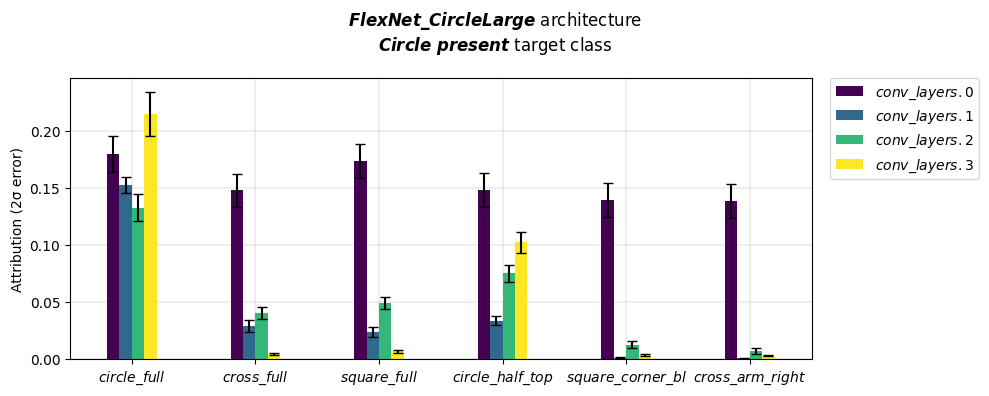

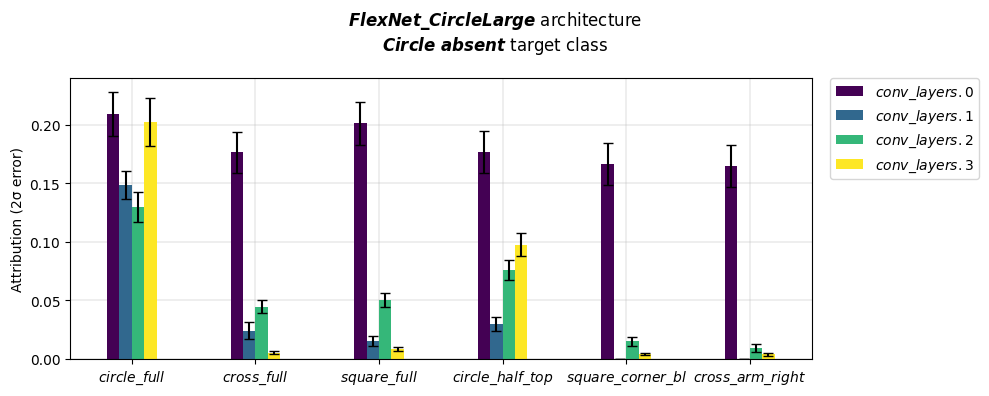

In [17]:
global_circle.plot()
global_no_circle.plot()

In [18]:
# --- Retrieve all conv layer names from the model ---
all_conv_layers = [name for name in vtcav_model.getLayerNames() if name.startswith('conv_layers.')]
print(f'Conv layers found: {all_conv_layers}\n')

local_clf = LocalVisualTCAV(
    test_image_filename=f'{img_with[0]:05d}.png',
    m_steps=50,
    model=vtcav_model,
    concept_images_dir=CONCEPTS_DIR,
    test_images_dir=TEST_IMAGES_DIR,
    random_images_folder='random_pool_4',
    cav_method='classifier',
    device=DEVICE,
)

local_clf.setConcepts(CONCEPTS)
local_clf.setLayers(all_conv_layers)

predictions_clf = local_clf.predict(no_sort=True)
local_clf.explain(cache_cav=False, cache_random=False)

# --- Print classifier-based CAVs per layer ---
print('=== Classifier-based CAVs ===')
for layer_name in all_conv_layers:
    print(f'\n--- {layer_name} ---')
    for concept_name in local_clf.concepts:
        cav = local_clf.getCAVs(layer_name, concept_name)
        attribs = local_clf.computations[layer_name][concept_name].attributions
        attribs = {k: v.item() if isinstance(v, torch.Tensor) else v for k, v in attribs.items()}
        print(f'  {concept_name}: accuracy={cav.accuracy:.3f}, attribs={attribs}')

# --- Print centroid-based CAVs per layer (from earlier explainer) ---
print('\n=== Centroid-based CAVs (from section 6) ===')
for layer_name in local_explainer.layers:
    print(f'\n--- {layer_name} ---')
    for concept_name in local_explainer.concepts:
        attribs = local_explainer.computations[layer_name][concept_name].attributions
        attribs = {k: v.item() if isinstance(v, torch.Tensor) else v for k, v in attribs.items()}
        print(f'  {concept_name}: attribs={attribs}')

Conv layers found: ['conv_layers.0', 'conv_layers.0.0', 'conv_layers.1', 'conv_layers.1.0', 'conv_layers.2', 'conv_layers.2.0', 'conv_layers.3', 'conv_layers.3.0']



Layers: 100%|██████████| 8/8 [00:07<00:00,  1.03it/s]

=== Classifier-based CAVs ===

--- conv_layers.0 ---
  circle_full: accuracy=1.000, attribs={0: 0.19166505336761475, 1: 0.14733418822288513}
  cross_full: accuracy=1.000, attribs={0: 0.1510404795408249, 1: 0.11180971562862396}
  square_full: accuracy=1.000, attribs={0: 0.1859586536884308, 1: 0.15824821591377258}
  circle_half_top: accuracy=1.000, attribs={0: 0.15302002429962158, 1: 0.11141102015972137}
  square_corner_bl: accuracy=1.000, attribs={0: 0.1487526148557663, 1: 0.04134374484419823}
  cross_arm_right: accuracy=1.000, attribs={0: 0.14882057905197144, 1: 0.03501416742801666}

--- conv_layers.0.0 ---
  circle_full: accuracy=0.975, attribs={0: 0.01766936294734478, 1: 0.0006807750323787332}
  cross_full: accuracy=0.985, attribs={0: 0.017652831971645355, 1: 0.0006767553859390318}
  square_full: accuracy=0.970, attribs={0: 0.017796535044908524, 1: 0.0007686027092859149}
  circle_half_top: accuracy=0.980, attribs={0: 0.01765451394021511, 1: 0.0006769270403310657}
  square_corner_bl: 

In [19]:
# --- Compare centroid vs classifier CAV directions across all shared layers ---
shared_layers = [l for l in all_conv_layers if l in local_explainer.layers]

print('Cosine similarity between centroid and classifier CAV directions:')
for layer_name in shared_layers:
    print(f'\n--- {layer_name} ---')
    for cn in concept_names:
        d_centroid = local_explainer.getCAVs(layer_name, cn).direction   # shape: [C]
        d_classifier = local_clf.getCAVs(layer_name, cn).direction       # shape: [C]
        cos = F.cosine_similarity(
            d_centroid.unsqueeze(0),   # [1, C]
            d_classifier.unsqueeze(0)  # [1, C]
        ).item()
        print(f'  {cn}: {cos:.4f}')

Cosine similarity between centroid and classifier CAV directions:

--- conv_layers.0 ---
  circle_full: 1.0000
  cross_full: 1.0000
  square_full: 1.0000
  circle_half_top: 1.0000
  square_corner_bl: 1.0000
  cross_arm_right: 1.0000

--- conv_layers.1 ---
  circle_full: 1.0000
  cross_full: 1.0000
  square_full: 1.0000
  circle_half_top: 1.0000
  square_corner_bl: 1.0000
  cross_arm_right: 1.0000

--- conv_layers.2 ---
  circle_full: 1.0000
  cross_full: 1.0000
  square_full: 1.0000
  circle_half_top: 1.0000
  square_corner_bl: 1.0000
  cross_arm_right: 1.0000

--- conv_layers.3 ---
  circle_full: 1.0000
  cross_full: 1.0000
  square_full: 1.0000
  circle_half_top: 1.0000
  square_corner_bl: 1.0000
  cross_arm_right: 1.0000


## Captum TCAV

In [20]:
  import glob
  from captum.concept import TCAV, Concept
  from captum.concept._utils.data_iterator import dataset_to_dataloader, CustomIterableDataset

  # --- Helper functions ---
  def get_tensor_from_filename(filename):
      img = Image.open(filename).convert("RGB")
      return pretrained_transforms(img)

  def assemble_concept(name, id, concepts_path):
      concept_path = os.path.join(concepts_path, name) + "/"
      dataset = CustomIterableDataset(get_tensor_from_filename, concept_path)
      concept_iter = dataset_to_dataloader(dataset)
      return Concept(id=id, name=name, data_iter=concept_iter)

  def load_test_images(class_dir):
      """Load all test images from a directory as a batch tensor."""
      tensors = []
      for f in sorted(glob.glob(os.path.join(class_dir, '*'))):
          img = Image.open(f).convert('RGB')
          tensors.append(pretrained_transforms(img))
      return torch.stack(tensors)